# ARCH-family Pipeline

---

In [1]:
# Libraries
import math
import json
import warnings
import hashlib

import numpy as np
import pandas as pd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

from pathlib import Path
from dataclasses import dataclass
from typing import Iterable, Optional, Literal, Any

from tqdm.auto import tqdm
from tabulate import tabulate

# Statistical modelling
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Statistical diagnostics
from arch import arch_model
from statsmodels.tsa.seasonal import STL
from statsmodels.stats.diagnostic import het_arch, acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf

# SciPy stats
from scipy import stats
from scipy.stats import norm, kstest
from scipy.special import inv_boxcox

warnings.filterwarnings("ignore")

---

    - Function to format results into a table

In [2]:
def display_table(df: pd.DataFrame, title: str):
    """
    Display a formatted table for quick analysis and validation of results.

    Parameters
    ----------
    df (pd.DataFrame): DataFrame to be displayed.
    title (str): Title printed above the table.


    Returns
    -------
    df (pd.DataFrame)
    """

    print(f"\n{title}")
    if df is None:
        print("⚠️ No data provided.")
        return

    if isinstance(df, pd.Series):
        df = df.to_frame()

    if not isinstance(df, pd.DataFrame):
        print("⚠️ Invalid data format.")
        return

    if df.empty or df.shape[1] == 0:
        print("⚠️ No valid data or columns not found.")
        return

    colalign = ["center"] * len(df.columns)
    print(tabulate(df, headers="keys", tablefmt="fancy_grid", colalign=colalign, showindex=True, floatfmt=".8f"))

    - Function to compute Freedman–Diaconis bins

In [3]:
def freedman_diaconis_bins(df: pd.DataFrame):
    """
    Compute the number of histogram bins using the Freedman–Diaconis rule.
    The FD rule sets the bin width as: width = 2 * IQR / n^(1/3), where IQR is the interquartile range (Q3 - Q1) and n is the sample size.

    Parameters
    ----------
    df (pd.DataFrame): One-dimensional numeric data.

    Returns
    -------
    n_bins (int): Suggested number of bins.
    iqr_range (float): Suggested bin IQR range.
    """

    # Length of dataframe
    n = df.size
    if n == 0:
        return print("Dataframe is empty")
    
    # IQR range calculation
    q75, q25 = np.percentile(df, [75, 25])
    iqr = q75 - q25
    iqr_range = 2.0 * iqr / (n**(1/3))

    # Bins calculation
    data_range = np.max(df) - np.min(df)
    n_bins = int(math.ceil(data_range / iqr_range)) if iqr_range > 0 else 1

    return n_bins, iqr_range

---

## Upload and verification of Time-Series data

In [4]:
# Upload of Time-Series data
def load_series_from_csv(csv_path: str | Path, value_col: str, index_col: int | str = 0, dayfirst: bool = True, sort_index: bool = True, name: str = "y"):
    """
    Load a univariate time series from a CSV file.

    Notes
    -----
    - Expects the time index in `index_col`.
    - Converts index to datetime.
    - Returns a pd.Series with a clean name.
    """
    
    csv_path = Path(csv_path)
    df_raw = pd.read_csv(csv_path, index_col=index_col)
    df_raw.index = pd.to_datetime(df_raw.index, dayfirst=dayfirst, errors="coerce")
    df_raw = df_raw.rename_axis("Date")

    if df_raw.index.isna().any():
        raise ValueError("Warning: Datetime conversion produced NaT values in the index. Please check the CSV index format.")

    if sort_index:
        if not df_raw.index.is_monotonic_increasing:
            df_raw = df_raw.sort_index()
            print("Warning: Datetime index was not sorted. It has been automatically sorted.")

    if value_col not in df_raw.columns:
        raise KeyError(f"Column '{value_col}' not found. Available columns: {list(df_raw.columns)}")

    y = df_raw[value_col].copy()
    
    y.name = name
    return y

df_path = r"D:\Hnsx\Formação Superior\0_Universidade Europeia\Mestrado em Ciência de Dados e Análise de Negócios\Curso\Tese_DataScience\Código\BTC-USD_2025-08-15.csv"
y_temp = load_series_from_csv(csv_path= df_path, value_col= "Close", name= "Close")

# Série de valores de fecho
y_close = y_temp.copy()
# y = y_close.copy()

ret_type = "L"          # "S" simple returns | "L" log returns

# Return series
if ret_type == "S":
    y_returns = pd.Series(y_temp.pct_change(), name=f"Returns({ret_type}) series").dropna()
elif ret_type == "L":
    y_returns = pd.Series(np.log(y_temp / y_temp.shift(1)), name=f"Returns({ret_type}) series").dropna()
else:
    raise ValueError("ret_type deve ser 'S' ou 'L'.")
y = y_returns.copy()

serie_cache_name = y.name.strip("'").split()[0]

In [5]:
# Time-Series data validation
def validate_series(y: pd.Series, min_len: int = 30):
    """
    Validate basic requirements for forecasting.

    - Ensures the input is a pandas Series
    - Ensures the series is not empty
    - Ensures no missing values exist (warns and stops execution)
    - Ensures minimum length requirement
    """
    
    if not isinstance(y, pd.Series):
        raise TypeError("Input must be a pandas Series.")

    if y.empty:
        raise ValueError("Series is empty.")

    y = y.copy()

    # Coerce to numeric if needed
    y = pd.to_numeric(y, errors="coerce")

    # Check for missing values (original NaN or coercion-induced NaN)
    n_missing = int(y.isna().sum())
    if n_missing > 0:
        warnings.warn(f"Series contains {n_missing} missing values. "
                      "Missing values must be treated before running the ETS pipeline.", category=UserWarning)
        raise ValueError("Pipeline stopped due to missing values. "
                         "Please handle NaNs explicitly (imputation, interpolation, or removal) before proceeding.")
    else:
        print("There is no missing values on dataset, pipeline is able to continue.")


    if len(y) < min_len:
        raise ValueError(f"Series too short for ETS pipeline (len={len(y)} < {min_len}).")

    return y

# Execute validation
data_verification = validate_series(y=y)

There is no missing values on dataset, pipeline is able to continue.


In [6]:
# Time-Series frequenci identification
def infer_frequency(y: pd.Series):
    """
    Infer the frequency of a DatetimeIndex.
    """

    freq = pd.infer_freq(y.index)

    if freq is None:
        warnings.warn("Could not reliably infer frequency from the DatetimeIndex. "
                      "Ensure the series is regular and without missing timestamps.")
        return None

    freq_map = {"D": "Daily",
                "B": "Business Daily",
                "W": "Weekly",
                "M": "Monthly",
                "Q": "Quarterly",
                "A": "Annual"}

    # Extract main frequency code
    main_freq = freq.split("-")[0]

    readable = freq_map.get(main_freq, f"Detected frequency: {freq}")

    print(f"Detected time frequency: {readable} ({freq})")

    return freq
    
y_freq = infer_frequency(y= y)

Detected time frequency: Daily (D)


In [7]:
# Evaluate seasonality strength via STL
def seasonal_strength_stl(y: pd.Series, period: int):
    """
    Compute seasonality strength using STL decomposition.

    Parameters
    ----------
    y (pd.Series): Time series to analyse.

    period (int): Candidate seasonal period.

    Returns
    -------
    float - Seasonality strength in [0, 1], or 0 if it cannot be computed.
    """

    if period is None or int(period) < 2:
        return 0

    y_clean = pd.Series(y).astype(float).replace([np.inf, -np.inf], np.nan).dropna()

    # STL needs enough observations and at least a few cycles
    if len(y_clean) < 2 * int(period) + 5:
        return 0

    try:
        stl = STL(y_clean, period=int(period), robust=True).fit()

        resid = stl.resid
        seasonal_plus_resid = stl.seasonal + stl.resid

        var_resid = np.nanvar(resid)
        var_sr = np.nanvar(seasonal_plus_resid)

        if not np.isfinite(var_resid) or not np.isfinite(var_sr) or var_sr <= 0:
            return 0

        strength = 1 - (var_resid / var_sr)

        return float(np.clip(strength, 0, 1))

    except Exception:
        return 0


def evaluate_seasonality(y: pd.Series, candidate_periods: Optional[Iterable[int]] = None):
    """
    Evaluate candidate seasonal periods using STL seasonality strength.

    Returns
    -------
    best_period (int | None): Period with highest estimated seasonality strength.

    best_strength (float): Highest estimated seasonality strength.

    details (dict): Dictionary with period -> strength.
    """

    if candidate_periods is None:
        candidate_periods = (2, 3, 4, 5, 6, 7, 12)

    y_clean = pd.Series(y).astype(float).replace([np.inf, -np.inf], np.nan).dropna()

    details = {}

    for p in candidate_periods:
        p = int(p)
        details[p] = seasonal_strength_stl(y_clean, p)

    if len(details) == 0:
        return None, 0, {}

    best_period = max(details, key=details.get)
    best_strength = float(details[best_period])

    return best_period, best_strength, details

y_freq = infer_frequency(y)

# Seasonality check on returns
r = y.copy()
r.name = "Returns"

candidate_periods = (5, 7, 15, 30, 60, 120, 365)
best_p_ret, best_s_ret, details_ret = evaluate_seasonality(y=r, candidate_periods=candidate_periods)

print("Best seasonal period:", best_p_ret)
print("Best seasonal strength:", round(best_s_ret, 4))

seasonal_summary_ret = (pd.DataFrame({"period": list(details_ret.keys()), "strength": list(details_ret.values())}).sort_values("strength", ascending=False).reset_index(drop=True))
seasonal_summary_ret["period"] = seasonal_summary_ret["period"].astype(int).astype(str)
display_table(seasonal_summary_ret, f"Seasonal strength table of {r.name}:")

Detected time frequency: Daily (D)
Best seasonal period: 120
Best seasonal strength: 0.1291

Seasonal strength table of Returns:
╒════╤══════════╤════════════╕
│    │  period  │   strength │
╞════╪══════════╪════════════╡
│ 0  │   120    │ 0.12914079 │
├────┼──────────┼────────────┤
│ 1  │    15    │ 0.10566964 │
├────┼──────────┼────────────┤
│ 2  │   365    │ 0.09080693 │
├────┼──────────┼────────────┤
│ 3  │    30    │ 0.08894658 │
├────┼──────────┼────────────┤
│ 4  │    60    │ 0.08375077 │
├────┼──────────┼────────────┤
│ 5  │    5     │ 0.06681629 │
├────┼──────────┼────────────┤
│ 6  │    7     │ 0.05070355 │
╘════╧══════════╧════════════╛


In [8]:
# Time-based train/val/test split
def time_split(y: pd.Series, test_size: float = 0.2, test_start: Optional[str | pd.Timestamp] = None, val_size: float = 0.3):
    """
    Split a time series into train/val/test.

    Parameters
    ----------
    test_start : str | pd.Timestamp | None
        If provided, test starts at this timestamp (inclusive).
        If None, uses test_size percentage.
    val_size : float
        Fraction of the training portion used as validation (0 disables validation split).

    Returns
    -------
    y_train, y_val, y_test
    """
    y = y.copy()
    if test_start is not None:
        test_start = pd.to_datetime(test_start)
        y_train_full = y.loc[y.index < test_start]
        y_test = y.loc[y.index >= test_start]
        if y_train_full.empty or y_test.empty:
            raise ValueError("Date-based split produced empty train or test. Check test_start.")
    else:
        if not (0 < test_size < 1):
            raise ValueError("test_size must be in (0,1).")
        cut = int(len(y) * (1 - test_size))
        y_train_full = y.iloc[:cut]
        y_test = y.iloc[cut:]
        if y_train_full.empty or y_test.empty:
            raise ValueError("Percentage split produced empty train or test. Adjust test_size.")

    if not (0 < val_size < 1):
        raise ValueError("val_size must be in (0,1).")

    cut_val = int(len(y_train_full) * (1 - val_size))
    y_train = y_train_full.iloc[:cut_val]
    y_val = y_train_full.iloc[cut_val:]

    if y_train.empty or y_val.empty:
        raise ValueError("Validation split produced empty train or val. Adjust val_size.")

    return y_train, y_val, y_test

y_train, y_val, y_test = time_split(y= y, test_start= None, val_size= 0.3)
print(f"Lenght of training dataset: {len(y_train)}")
print(f"Lenght of validation dataset: {len(y_val)}")
print(f"Lenght of test dataset: {len(y_test)}")

Lenght of training dataset: 2230
Lenght of validation dataset: 957
Lenght of test dataset: 797


In [9]:
# Seasonality check on volatility proxy
v = y.pow(2).copy()
v.name = "Squared Returns"

candidate_periods = (5, 7, 15, 30, 60, 120, 365)

best_p, best_s, details = evaluate_seasonality(y=v, candidate_periods=candidate_periods)

print("Best seasonal period:", best_p)
print("Best seasonal strength:", round(best_s, 4))

seasonal_summary = (pd.DataFrame({ "period": list(details.keys()), "strength": list(details.values())}).sort_values("strength", ascending=False).reset_index(drop=True))

seasonal_summary["period"] = seasonal_summary["period"].astype(int).astype(str)

display_table(seasonal_summary, f"Seasonal strength table of {v.name}:")

Best seasonal period: 365
Best seasonal strength: 0.5148

Seasonal strength table of Squared Returns:
╒════╤══════════╤════════════╕
│    │  period  │   strength │
╞════╪══════════╪════════════╡
│ 0  │   365    │ 0.51480359 │
├────┼──────────┼────────────┤
│ 1  │    5     │ 0.07200456 │
├────┼──────────┼────────────┤
│ 2  │    60    │ 0.06347951 │
├────┼──────────┼────────────┤
│ 3  │    7     │ 0.04992226 │
├────┼──────────┼────────────┤
│ 4  │   120    │ 0.04655920 │
├────┼──────────┼────────────┤
│ 5  │    15    │ 0.03395419 │
├────┼──────────┼────────────┤
│ 6  │    30    │ 0.00000000 │
╘════╧══════════╧════════════╛


In [10]:
# Evaluate volatility clustering and ARCH effects using the original return series
def volatility_clustering_strength(returns: pd.Series, nlags: int = 20):
    """
    Evaluate whether the return series shows evidence of volatility clustering.

    Parameters
    ----------
    returns (pd.Series): Return series r_t.

    nlags (int, default=20): Number of lags used in autocorrelation diagnostics and ARCH-LM test.

    Returns
    -------
    dict
        Dictionary with:
        - acf_abs_max: maximum absolute ACF of |returns| over lags 1..nlags
        - acf_sq_max: maximum absolute ACF of returns² over lags 1..nlags
        - arch_lm_stat: ARCH-LM test statistic
        - arch_lm_pvalue: ARCH-LM test p-value
        - has_arch_effects: whether ARCH effects are detected at 5%
    """

    if not isinstance(returns, pd.Series):
        raise TypeError("returns must be a pandas Series.")

    r = (returns.astype(float).replace([np.inf, -np.inf], np.nan).dropna().copy()    )

    if len(r) < nlags + 5:
        return {"acf_abs_max": 0, "acf_sq_max": 0, "arch_lm_stat": np.nan, "arch_lm_pvalue": np.nan, "has_arch_effects": False}

    abs_r = r.abs()
    sq_r = r.pow(2)

    acf_abs_vals = acf(abs_r, nlags=nlags, fft=False)
    acf_sq_vals = acf(sq_r, nlags=nlags, fft=False)

    acf_abs_max = (float(np.max(np.abs(acf_abs_vals[1:]))) if len(acf_abs_vals) > 1 else 0)

    acf_sq_max = (float(np.max(np.abs(acf_sq_vals[1:]))) if len(acf_sq_vals) > 1 else 0)

    try:
        lm_stat, lm_pvalue, _, _ = het_arch(r, nlags=nlags)

        arch_lm_stat = float(lm_stat)
        arch_lm_pvalue = float(lm_pvalue)
        has_arch_effects = bool(arch_lm_pvalue < 0.05)

    except Exception:
        arch_lm_stat = np.nan
        arch_lm_pvalue = np.nan
        has_arch_effects = False

    return {"acf_abs_max": acf_abs_max,
            "acf_sq_max": acf_sq_max,
            "arch_lm_stat": arch_lm_stat,
            "arch_lm_pvalue": arch_lm_pvalue,
            "has_arch_effects": has_arch_effects}


def evaluate_garch_relevance(returns: pd.Series, nlags: int = 20) -> pd.DataFrame:
    """
    Summarise whether the original return series is a suitable candidate
    for ARCH/GARCH-family modelling.

    Notes
    -----
    ARCH/GARCH relevance should be assessed from the original return series, even when the empirical evaluation target is the squared-return volatility proxy.
    """

    diag = volatility_clustering_strength(returns=returns, nlags=nlags)

    summary = pd.DataFrame({"Metric": ["Max |ACF| of |returns|",
                                       "Max |ACF| of returns²",
                                       "ARCH-LM statistic",
                                       "ARCH-LM p-value",
                                       "ARCH effects detected (5%)"],
                            
                            "Value": [diag["acf_abs_max"],
                                      diag["acf_sq_max"],
                                      diag["arch_lm_stat"],
                                      diag["arch_lm_pvalue"],
                                      diag["has_arch_effects"]]})

    return summary

# Volatility proxy used for empirical evaluation
y_vol = y.pow(2).copy()
y_vol.name = "Squared returns volatility proxy"

# ARCH/GARCH relevance diagnostic based on returns
garch_diag_summary = evaluate_garch_relevance(returns=y, nlags=20)

display_table(garch_diag_summary, "Volatility clustering / ARCH effects diagnostics:")


Volatility clustering / ARCH effects diagnostics:
╒════╤════════════════════════════╤══════════════╕
│    │           Metric           │        Value │
╞════╪════════════════════════════╪══════════════╡
│ 0  │   Max |ACF| of |returns|   │   0.20732410 │
├────┼────────────────────────────┼──────────────┤
│ 1  │   Max |ACF| of returns²    │   0.13220712 │
├────┼────────────────────────────┼──────────────┤
│ 2  │     ARCH-LM statistic      │ 146.15769933 │
├────┼────────────────────────────┼──────────────┤
│ 3  │      ARCH-LM p-value       │   0.00000000 │
├────┼────────────────────────────┼──────────────┤
│ 4  │ ARCH effects detected (5%) │   1.00000000 │
╘════╧════════════════════════════╧══════════════╛


---

## Criação dos modelos ARCH-family

In [11]:
# Multi-horizon backtesting block generator for GARCH train CV
BacktestMode = Literal["rolling", "expanding", "none"]


@dataclass(frozen=True)
class BacktestBlock:
    """
    Single origin block for multi-horizon GARCH evaluation.
    """
    origin: int
    train: pd.Series
    test: pd.Series


def generate_garch_backtest_blocks(y: pd.Series, horizons: Iterable[int], mode: BacktestMode = "rolling", window: Optional[int] = None, step: int = 1):
    """
    Generate backtesting blocks for multi-horizon GARCH cross-validation.

    Parameters
    ----------
    y (pd.Series): Return series used for backtesting. For GARCH-family models, this should be the return series r_t, not the squared-return volatility proxy.

    horizons (Iterable[int]): Forecast horizons to evaluate, e.g. (1, 7, 15, 30, 120).

    mode ({"rolling", "expanding", "none"}, default="rolling"): Backtesting scheme.

    window (int | None, default=None): Training window size. If None, defaults to 60% of the series length.

    step (int, default=1): Step size between consecutive forecast origins.

    Returns
    -------
    list[BacktestBlock]: List of backtesting blocks.
    """

    if not isinstance(y, pd.Series):
        raise TypeError("y must be a pandas Series.")

    if mode not in ("rolling", "expanding", "none"):
        raise ValueError("Invalid mode. Use 'rolling', 'expanding', or 'none'.")

    y = y.astype(float).replace([np.inf, -np.inf], np.nan).dropna().copy()

    horizons = tuple(sorted(set(int(h) for h in horizons)))

    if len(horizons) == 0:
        raise ValueError("horizons cannot be empty.")

    if any(h < 1 for h in horizons):
        raise ValueError("All horizons must be >= 1.")

    if step < 1:
        raise ValueError("step must be >= 1.")

    n = len(y)
    hmax = max(horizons)

    if window is None:
        window = int(n * 0.6)

    window = int(window)

    if window < 1:
        raise ValueError("window must be >= 1.")

    if n < window + hmax:
        raise ValueError(f"Series too short for requested horizons: need >= {window + hmax}, got {n}.")

    blocks: list[BacktestBlock] = []

    if mode == "none":
        origin = window
        train = y.iloc[:origin].copy()
        test = y.iloc[origin:origin + hmax].copy()

        blocks.append(BacktestBlock(origin=origin, train=train, test=test))

        return blocks

    start_origin = window
    end_origin = n - hmax

    for origin in range(start_origin, end_origin + 1, step):

        if mode == "rolling":
            train_start = origin - window
            train = y.iloc[train_start:origin].copy()

        elif mode == "expanding":
            train = y.iloc[:origin].copy()

        test = y.iloc[origin:origin + hmax].copy()

        blocks.append(BacktestBlock(origin=origin, train=train, test=test))

    return blocks

In [12]:
# Metrics RMSE, MAPE, sMAPE and QLIKE
def rmse(y_true: np.ndarray, y_pred: np.ndarray):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)

    if not np.any(mask):
        return np.nan
    
    rmse_result = float(np.sqrt(np.nanmean((y_true - y_pred) ** 2)))
    return rmse_result

def mape_smape(y_true: np.ndarray, y_pred: np.ndarray, eps: float = 1e-12):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)

    if not np.any(mask):
        return np.nan
    
    mape = float(np.nanmean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))) * 100)
    smape = float(np.nanmean(2 * np.abs(y_true - y_pred) / np.maximum(np.abs(y_true) + np.abs(y_pred), eps)) * 100)
    return mape, smape

def qlike(y_true: np.ndarray, y_pred: np.ndarray, eps: float = 1e-12):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)

    if not np.any(mask):
        return np.nan
    
    qlike_result = float(np.nanmean(np.log(np.maximum(y_pred, eps)) + (np.maximum(y_true, eps) / (np.maximum(y_pred, eps)))))
    return qlike_result

In [13]:
# GARCH configuration dataclass
GARCHModelType = Literal["ARCH", "GARCH", "GJR-GARCH", "EGARCH"]
GARCHMeanType = Literal["Zero", "Constant", "AR"]
GARCHDistType = Literal["normal", "gaussian", "t", "skewstudent", "ged"]

@dataclass(frozen=True)
class GARCHConfig:
    model: GARCHModelType
    mean: GARCHMeanType
    p: int
    o: int
    q: int
    dist: GARCHDistType

    def to_label(self):
        return (f"{self.model}(mean='{self.mean}', p={self.p}, o={self.o}, q={self.q}, dist='{self.dist}')") 

In [14]:
# GARCH configuration grid builder
def build_garch_config_grid(model_values: Iterable[GARCHModelType] = ("ARCH", "GARCH", "GJR-GARCH", "EGARCH"),
                            mean_values: Iterable[GARCHMeanType] = ("Zero", "Constant"),
                            p_values: Iterable[int] = (1, 2, 3),
                            o_values: Iterable[int] = (0, 1),
                            q_values: Iterable[int] = (0, 1, 2, 3),
                            dist_values: Iterable[GARCHDistType] = ("normal", "t", "skewstudent", "ged")):
    """
    Build a compact and valid volatility-model configuration grid.

    Supported models
    ----------------
    - ARCH
    - GARCH
    - GJR-GARCH
    - EGARCH
    """

    grid = []

    for model in model_values:
        for mean in mean_values:
            for p in p_values:
                for o in o_values:
                    for q in q_values:
                        for dist in dist_values:

                            # ARCH: only ARCH terms, arch_model should not use q or o
                            if model == "ARCH":
                                if q != 0 or o != 0:
                                    continue

                            # GARCH: ARCH + GARCH terms, no asymmetry, so o should be 0
                            elif model == "GARCH":
                                if q == 0 or o != 0:
                                    continue

                            # GJR-GARCH: q > 0 and o > 0
                            elif model == "GJR-GARCH":
                                if q == 0 or o == 0:
                                    continue

                            # EGARCH: allow asymmetry and/or GARCH persistence; with p_values >= 1, all-zero is impossible
                            elif model == "EGARCH":
                                if p == 0 and o == 0 and q == 0:
                                    continue

                            else:
                                raise ValueError(f"Unsupported model: {model}")

                            grid.append(GARCHConfig(model=model, mean=mean, p=p, o=o, q=q, dist=dist))

    return grid

In [15]:
# ARCH configuration compatibility check
def is_arch_config_compatible(y: pd.Series, cfg: GARCHConfig):
    """
    Check whether an ARCH-family configuration is compatible with the input series.
    This function performs preventive validation before model fitting. It does not guarantee convergence, but avoids structurally invalid configurations.
    """

    if not isinstance(y, pd.Series):
        return False

    if not isinstance(cfg, GARCHConfig):
        return False

    y_clean = (y.astype(float).replace([np.inf, -np.inf], np.nan).dropna().copy())

    if len(y_clean) == 0:
        return False

    if cfg.model not in ("ARCH", "GARCH", "GJR-GARCH", "EGARCH"):
        return False

    if cfg.mean not in ("Zero", "Constant", "AR"):
        return False

    if cfg.dist not in ("normal", "gaussian", "t", "skewstudent", "ged"):
        return False

    if cfg.p < 0 or cfg.o < 0 or cfg.q < 0:
        return False

    if cfg.p == 0 and cfg.o == 0 and cfg.q == 0:
        return False

    # Model-specific structural constraints
    if cfg.model == "ARCH":
        # ARCH uses ARCH terms only
        if cfg.o != 0 or cfg.q != 0:
            return False

    elif cfg.model == "GARCH":
        # Standard GARCH uses ARCH + GARCH terms, no asymmetry
        if cfg.o != 0 or cfg.q == 0:
            return False

    elif cfg.model == "GJR-GARCH":
        # GJR-GARCH uses asymmetry and GARCH persistence
        if cfg.o == 0 or cfg.q == 0:
            return False

    elif cfg.model == "EGARCH":
        # EGARCH may use p, o, q, but not all zero
        pass

    # Conservative minimum sample size rule
    n_params_proxy = cfg.p + cfg.o + cfg.q

    if len(y_clean) <= (n_params_proxy + 10):
        return False

    # Avoid fitting on a nearly constant series
    if np.isclose(y_clean.std(), 0):
        return False

    return True

In [16]:
# ARCH-family fitting and forecasting
def forecast_arch(y_train: pd.Series, h: int, cfg: GARCHConfig, simulations: int = 1000, random_state: int = 42, eps: float = 1e-12):
    """
    Fit an ARCH-family model and forecast h steps ahead.

    Parameters
    ----------
    y_train (pd.Series): Return series available before the forecast origin.

    h (int): Forecast horizon.

    cfg (GARCHConfig): GARCH-family configuration.

    simulations (int, default=1000): Number of simulations used when analytical forecasts are not available.

    random_state (int, default=42): Random seed for simulation-based forecasts.

    eps (float, default=1e-12): Minimum value imposed on variance forecasts.

    Returns
    -------
    (np.ndarray): Forecasted conditional variance for horizons 1..h.
    """

    y_train = (pd.Series(y_train).astype(float).replace([np.inf, -np.inf], np.nan).dropna())

    if len(y_train) == 0:
        raise ValueError("y_train is empty after removing missing values.")

    if h < 1:
        raise ValueError("h must be >= 1.")

    if not is_arch_config_compatible(y_train, cfg):
        raise ValueError(f"Selected config is not compatible: {cfg.to_label()}")

    # Map model label to arch package volatility specification
    if cfg.model == "ARCH":
        vol = "GARCH"
        p, o, q = cfg.p, 0, 0
        forecast_method = "analytic"

    elif cfg.model == "GARCH":
        vol = "GARCH"
        p, o, q = cfg.p, 0, cfg.q
        forecast_method = "analytic"

    elif cfg.model == "GJR-GARCH":
        vol = "GARCH"
        p, o, q = cfg.p, cfg.o, cfg.q
        forecast_method = "analytic" if h == 1 else "simulation"

    elif cfg.model == "EGARCH":
        vol = "EGARCH"
        p, o, q = cfg.p, cfg.o, cfg.q
        forecast_method = "analytic" if h == 1 else "simulation"

    else:
        raise ValueError(f"Unsupported model: {cfg.model}")

    model = arch_model(y_train, mean=cfg.mean, vol=vol, p=p, o=o, q=q, dist=cfg.dist)

    fit = model.fit(disp="off", show_warning=False)

    try:
        if forecast_method == "analytic":
            fcst = fit.forecast(horizon=h, reindex=False, method="analytic")
        else:
            fcst = fit.forecast(horizon=h, reindex=False, method="simulation", simulations=simulations, random_state=np.random.RandomState(random_state))

    except Exception:
        # Fallback for cases where analytical forecasts are not available
        fcst = fit.forecast(horizon=h, reindex=False, method="simulation", simulations=simulations, random_state=np.random.RandomState(random_state))

    # Extract forecasted conditional variance for the last origin
    var_hat = np.asarray(fcst.variance.iloc[-1], dtype=float)

    # Ensure strictly positive variance forecasts
    var_hat = np.maximum(var_hat, eps)

    if len(var_hat) < h:
        raise ValueError(f"Forecast returned fewer than h={h} steps.")

    return var_hat[:h]

In [17]:
# Evaluate a list of ARCH-family configs on a single origin
def evaluate_arch_configs_single_origin(r_train: pd.Series, r_test: pd.Series, cfgs: list[GARCHConfig], horizons: Iterable[int], metric: str = "RMSE"):
    """
    Evaluate a fixed list of ARCH-family configurations on a single forecast origin.

    Notes
    -----
    - r_train is the return series used to fit the ARCH-family model.
    - r_test is the future return series after the forecast origin.
    - Forecasts are conditional variance estimates.
    - Observed values are evaluated as the volatility proxy r_t².
    - Metrics are computed point-by-point for each horizon, matching the ARIMA logic.
    """

    horizons = tuple(sorted(set(int(h) for h in horizons)))

    if len(horizons) == 0:
        raise ValueError("horizons cannot be empty.")

    if any(h <= 0 for h in horizons):
        raise ValueError("All horizons must be positive integers.")

    metric = metric.upper()

    if metric not in ("RMSE", "MAPE", "SMAPE", "QLIKE"):
        raise ValueError("metric must be one of: 'RMSE', 'MAPE', 'SMAPE', 'QLIKE'.")

    hmax = max(horizons)

    r_train = (pd.Series(r_train).astype(float).replace([np.inf, -np.inf], np.nan).dropna().copy())
    r_test = (pd.Series(r_test).astype(float).replace([np.inf, -np.inf], np.nan).dropna().copy())

    if len(r_test) < hmax:
        raise ValueError(f"Test series too short for hmax={hmax}. len(r_test)={len(r_test)}")

    # Observed volatility proxy for evaluation
    y_true_hmax = r_test.pow(2).iloc[:hmax].values.astype(float)

    rows = []
    forecast_rows = []

    for cfg in cfgs:

        base_row = {"model": cfg.model,
                    "mean": cfg.mean,
                    "p": int(cfg.p),
                    "o": int(cfg.o),
                    "q": int(cfg.q),
                    "dist": cfg.dist,
                    "fit_attempted": 1,
                    "fit_success": 0,
                    "fit_failed": 0}

        if not is_arch_config_compatible(r_train, cfg):
            row = base_row.copy()
            row["fit_attempted"] = 0
            row["fit_success"] = 0
            row["fit_failed"] = 1

            for h in horizons:
                row[f"RMSE-h={h}"] = np.nan
                row[f"MAPE-h={h}"] = np.nan
                row[f"SMAPE-h={h}"] = np.nan
                row[f"QLIKE-h={h}"] = np.nan

            row["score_rmse_mean"] = np.nan
            row["score_mape_mean"] = np.nan
            row["score_smape_mean"] = np.nan
            row["score_qlike_mean"] = np.nan
            row["score_selected"] = np.nan

            rows.append(row)
            continue

        try:
            # Forecast conditional variance sigma_t²
            y_hat_hmax = forecast_arch(y_train=r_train, h=hmax, cfg=cfg)

            y_hat_hmax = np.asarray(y_hat_hmax, dtype=float)

            row = base_row.copy()
            row["fit_success"] = 1
            row["fit_failed"] = 0

            rmse_list = []
            mape_list = []
            smape_list = []
            qlike_list = []

            for h in horizons:
                # Point-specific horizon evaluation
                y_true = np.asarray([y_true_hmax[h - 1]], dtype=float)
                y_pred = np.asarray([y_hat_hmax[h - 1]], dtype=float)

                row[f"RMSE-h={h}"] = rmse(y_true, y_pred)
                row[f"MAPE-h={h}"], row[f"SMAPE-h={h}"] = mape_smape(y_true, y_pred)
                row[f"QLIKE-h={h}"] = qlike(y_true, y_pred)

                rmse_list.append(row[f"RMSE-h={h}"])
                mape_list.append(row[f"MAPE-h={h}"])
                smape_list.append(row[f"SMAPE-h={h}"])
                qlike_list.append(row[f"QLIKE-h={h}"])

                forecast_rows.append({"model": cfg.model,
                                      "mean": cfg.mean,
                                      "p": int(cfg.p),
                                      "o": int(cfg.o),
                                      "q": int(cfg.q),
                                      "dist": cfg.dist,
                                      "horizon": int(h),
                                      "y_true_vol_proxy": float(y_true[0]),
                                      "forecast": float(y_pred[0]),
                                      "residual": float(y_true[0] - y_pred[0])})

            row["score_rmse_mean"] = float(np.nanmean(rmse_list))
            row["score_mape_mean"] = float(np.nanmean(mape_list))
            row["score_smape_mean"] = float(np.nanmean(smape_list))
            row["score_qlike_mean"] = float(np.nanmean(qlike_list))

            if metric == "RMSE":
                row["score_selected"] = row["score_rmse_mean"]
            elif metric == "MAPE":
                row["score_selected"] = row["score_mape_mean"]
            elif metric == "SMAPE":
                row["score_selected"] = row["score_smape_mean"]
            elif metric == "QLIKE":
                row["score_selected"] = row["score_qlike_mean"]

            rows.append(row)

        except Exception:
            row = base_row.copy()
            row["fit_success"] = 0
            row["fit_failed"] = 1

            for h in horizons:
                row[f"RMSE-h={h}"] = np.nan
                row[f"MAPE-h={h}"] = np.nan
                row[f"SMAPE-h={h}"] = np.nan
                row[f"QLIKE-h={h}"] = np.nan

            row["score_rmse_mean"] = np.nan
            row["score_mape_mean"] = np.nan
            row["score_smape_mean"] = np.nan
            row["score_qlike_mean"] = np.nan
            row["score_selected"] = np.nan

            rows.append(row)

    df_results = pd.DataFrame(rows)
    df_forecasts = pd.DataFrame(forecast_rows)

    if not df_results.empty:
        df_results = (df_results.sort_values("score_selected", ascending=True, na_position="last").reset_index(drop=True))

    return df_results, df_forecasts

In [18]:
# ARCH-family CV within training set and aggregate results
def arch_cv_train_select(y_train: pd.Series, horizons: Iterable[int], mode: BacktestMode = "rolling", step: int = 1,
                         model_values: Iterable[str] = ("ARCH", "GARCH", "GJR-GARCH", "EGARCH"), mean_values: Iterable[str] = ("Zero", "Constant"),
                         p_values: Iterable[int] = (1, 2, 3), o_values: Iterable[int] = (0, 1), q_values: Iterable[int] = (0, 1, 2, 3),
                         dist_values: Iterable[str] = ("normal", "t", "skewstudent"), metric: str = "RMSE", top_k: int = 10):
    """
    Apply cross-validation only within the training set using rolling/expanding blocks, aggregate results per configuration, and return a compact package of outputs.

    Notes
    -----
    - y_train must be the original return series.
    - ARCH-family models are fitted on returns.
    - Forecasts are conditional variance estimates.
    - Evaluation is performed against returns² as the empirical volatility proxy.
    """

    if not isinstance(y_train, pd.Series):
        raise TypeError("y_train must be a pandas Series.")

    y_train_cv = (y_train.astype(float).replace([np.inf, -np.inf], np.nan).dropna().copy())

    horizons = tuple(sorted(set(int(h) for h in horizons)))

    if len(horizons) == 0:
        raise ValueError("horizons cannot be empty.")

    if any(h <= 0 for h in horizons):
        raise ValueError("All horizons must be positive integers.")

    metric = metric.upper()

    if metric not in ("RMSE", "MAPE", "SMAPE", "QLIKE"):
        raise ValueError("metric must be one of: 'RMSE', 'MAPE', 'SMAPE', 'QLIKE'.")

    hmax = max(horizons)

    train_w = int(len(y_train_cv) * 0.6)
    train_w = max(train_w, 30)
    train_w = min(train_w, len(y_train_cv) - hmax)

    if train_w < 10:
        raise ValueError(f"Training window too small for CV (train_w={train_w}). Increase y_train length or reduce horizons (hmax={hmax}).")

    blocks = generate_garch_backtest_blocks(y=y_train_cv, horizons=horizons, mode=mode, window=train_w, step=step)

    cfgs = build_garch_config_grid(model_values=model_values, mean_values=mean_values, p_values=p_values, o_values=o_values, q_values=q_values, dist_values=dist_values)

    per_origin = []
    forecast_frames = []

    for b in tqdm(blocks, desc="ARCH-family CV (train) - origins", unit="origin"):

        # b.train and b.test are return series
        df_origin, df_forecast = evaluate_arch_configs_single_origin(r_train=b.train, r_test=b.test, cfgs=cfgs, horizons=horizons, metric=metric)

        if not df_origin.empty:
            df_origin["origin"] = b.origin
            per_origin.append(df_origin)

        if not df_forecast.empty:
            df_forecast["origin"] = b.origin
            forecast_frames.append(df_forecast)

    df_all = (pd.concat(per_origin, ignore_index=True) if len(per_origin) else pd.DataFrame())

    df_forecasts = (pd.concat(forecast_frames, ignore_index=True) if len(forecast_frames) else pd.DataFrame())

    if df_all.empty:
        summary = pd.DataFrame()
        top = pd.DataFrame()

    else:
        group_cols = ["model", "mean", "p", "o", "q", "dist"]

        rmse_cols = sorted([c for c in df_all.columns if c.startswith("RMSE-h=")], key=lambda x: int(x.split("=")[1]))
        mape_cols = sorted([c for c in df_all.columns if c.startswith("MAPE-h=")], key=lambda x: int(x.split("=")[1]))
        smape_cols = sorted([c for c in df_all.columns if c.startswith("SMAPE-h=")], key=lambda x: int(x.split("=")[1]))
        qlike_cols = sorted([c for c in df_all.columns if c.startswith("QLIKE-h=")], key=lambda x: int(x.split("=")[1]))

        score_cols = ["score_rmse_mean", "score_mape_mean", "score_smape_mean", "score_qlike_mean", "score_selected"]

        metric_cols = (rmse_cols + mape_cols + smape_cols + qlike_cols + score_cols)
        metric_cols = [c for c in metric_cols if c in df_all.columns]

        # Mean metrics across successful fits only
        summary_metrics = (df_all[df_all["fit_success"] == 1].groupby(group_cols, dropna=False)[metric_cols].mean())

        # Fit statistics across all attempts
        summary_fit = (df_all.groupby(group_cols, dropna=False)[["fit_attempted", "fit_success", "fit_failed"]].sum())

        summary = summary_fit.join(summary_metrics, how="left").reset_index()

        summary["n_attempts"] = summary["fit_attempted"].astype(int)
        summary["n_success"] = summary["fit_success"].astype(int)
        summary["n_fail"] = summary["fit_failed"].astype(int)

        summary["success_rate"] = np.where(summary["n_attempts"] > 0, summary["n_success"] / summary["n_attempts"], np.nan)

        summary = summary.drop(columns=["fit_attempted", "fit_success", "fit_failed"])

        summary = (summary.sort_values("score_selected", ascending=True, na_position="last").reset_index(drop=True))

        top = summary.head(top_k).copy()

    return {"y_train_cv": y_train_cv,
            "train_w": train_w,
            "hmax": hmax,
            "blocks_n": len(blocks),
            "df_all_train": df_all,
            "df_forecasts_train": df_forecasts,
            "summary_train": summary,
            "top_train": top}

---

# Avaliação no conjunto de Treino

In [ ]:
# Caching mechanism for ARCH-family CV results on training set
def run_or_load_arch_train_search(cache_dir: str, cache_name: str, y_train: pd.Series, horizons: Iterable[int], mode: BacktestMode = "rolling",
                                  step: int = 1, model_values: Iterable[str] = ("ARCH", "GARCH", "GJR-GARCH", "EGARCH"),
                                  mean_values: Iterable[str] = ("Zero", "Constant"), p_values: Iterable[int] = (1, 2, 3),
                                  o_values: Iterable[int] = (0, 1), q_values: Iterable[int] = (0, 1, 2, 3),
                                  dist_values: Iterable[str] = ("normal", "t", "skewstudent", "ged"),
                                  metric: str = "RMSE", top_k: int = 10):
    """
    Run ARCH-family cross-validation on the training set or load cached results from disk.

    The cache is only loaded when the metadata match the current input data, horizons,
    backtesting setup, ARCH-family hyperparameter grid and evaluation setup.

    Notes
    -----
    - y_train must be the original return series.
    - ARCH-family models are fitted on returns.
    - Forecasts are conditional variance estimates.
    - Evaluation is performed against returns² as the empirical volatility proxy.

    Parameters
    ----------
    cache_dir (str): Directory where training CV results are stored.

    cache_name (str): Cache folder name for the current ARCH-family training run.

    y_train (pd.Series): Training return series.

    horizons (Iterable[int]): Forecast horizons, for example (1, 7, 15, 30, 120).

    mode (BacktestMode, default="rolling"): Backtesting mode used to generate forecast-origin blocks.

    step (int, default=1): Step between forecast origins.

    model_values (Iterable[str]): Candidate ARCH-family model classes.

    mean_values (Iterable[str]): Candidate mean specifications.

    p_values (Iterable[int]): Candidate ARCH/GARCH lag orders.

    o_values (Iterable[int]): Candidate asymmetric lag orders.

    q_values (Iterable[int]): Candidate GARCH lag orders.

    dist_values (Iterable[str]): Candidate innovation distributions.

    metric (str, default="RMSE"): Main metric used for ranking configurations. Supported values: "RMSE", "MAPE", "SMAPE", "QLIKE".

    top_k (int, default=10): Number of top configurations to return.

    Returns
    -------
    out (dict): Dictionary containing cached or newly computed ARCH-family training CV results, forecasts and metadata.
    """

    def series_signature(y: pd.Series):
        """
        Create a deterministic signature for the input series based on values and index.
        """
        hashed = pd.util.hash_pandas_object(y, index=True).values.tobytes()
        return hashlib.sha256(hashed).hexdigest()

    def normalize_list(values):
        """
        Convert iterable values into JSON-compatible lists.
        """
        out = []

        for v in values:
            if v is None:
                out.append(None)
            elif isinstance(v, (int, float, str, bool)):
                out.append(v)
            else:
                out.append(str(v))

        return out

    metric = str(metric).upper()

    if metric not in ("RMSE", "MAPE", "SMAPE", "QLIKE"):
        raise ValueError("metric must be one of: 'RMSE', 'MAPE', 'SMAPE', 'QLIKE'.")

    cache_path = Path(cache_dir) / cache_name
    cache_path.mkdir(parents=True, exist_ok=True)

    meta_file = cache_path / "meta.json"
    df_all_file = cache_path / "df_all_train.pkl.gz"
    summary_file = cache_path / "summary_train.pkl.gz"
    top_file = cache_path / "top_train.pkl.gz"
    df_forecasts_file = cache_path / "df_forecasts_train.pkl.gz"

    y_train_clean = (pd.Series(y_train).astype(float).replace([np.inf, -np.inf], np.nan).dropna().copy())

    horizons_clean = list(sorted(set(int(h) for h in horizons)))

    expected_meta = {"model": "ARCH-family",
                     "horizons": horizons_clean,
                     "mode": mode,
                     "step": int(step),
                     
                     "model_values": normalize_list(model_values),
                     "mean_values": normalize_list(mean_values),
                     "p_values": normalize_list(p_values),
                     "o_values": normalize_list(o_values),
                     "q_values": normalize_list(q_values),
                     "dist_values": normalize_list(dist_values),
                     
                      "metric": metric,
                      "top_k": int(top_k),
                      
                      # Critical cache-validation fields
                      "input_series_type": "returns",
                      "forecast_object": "conditional_variance",
                      "evaluation_target": "squared_returns_volatility_proxy",
                      
                      "series_signature": series_signature(y_train_clean),
                      "series_length": int(len(y_train_clean)),
                      "series_start": str(y_train_clean.index.min()),
                      "series_end": str(y_train_clean.index.max()),
                      
                      "stored_forecasts": True,
                      "forecast_scale": "original_volatility_proxy"}

    # Load only if all files exist and metadata matches current input
    required_files_exist = (meta_file.exists() and
                            df_all_file.exists() and
                            summary_file.exists() and
                            top_file.exists() and
                            df_forecasts_file.exists())

    if required_files_exist:

        meta = json.loads(meta_file.read_text(encoding="utf-8"))

        keys_to_check = ["model",
                         "horizons",
                         "mode",
                         "step",
                         
                         "model_values",
                         "mean_values",
                         "p_values",
                         "o_values",
                         "q_values",
                         "dist_values",
                         
                         "metric",
                         "top_k",
                         
                         "input_series_type",
                         "forecast_object",
                         "evaluation_target",
                         
                         "series_signature",
                         "series_length",
                         "series_start",
                         "series_end",
                         
                         "stored_forecasts",
                         "forecast_scale"]

        cache_is_valid = all(meta.get(k) == expected_meta[k] for k in keys_to_check)

        if cache_is_valid:

            out = {"y_train_cv": y_train_clean.copy(),
                   "train_w": meta["train_w"],
                   "hmax": meta["hmax"],
                   "blocks_n": meta["blocks_n"],
                   "cfgs_n": meta.get("cfgs_n", None),
                   "compatible_cfgs_n": meta.get("compatible_cfgs_n", None),
                   "df_all_train": pd.read_pickle(df_all_file, compression="gzip"),
                   "summary_train": pd.read_pickle(summary_file, compression="gzip"),
                   "top_train": pd.read_pickle(top_file, compression="gzip"),
                   "df_forecasts_train": pd.read_pickle(df_forecasts_file, compression="gzip"),
                   "meta": meta}

            return out

        print("Warning: cache metadata does not match current input. Recomputing ARCH-family CV.")

    # Otherwise run ARCH-family CV
    out = arch_cv_train_select(y_train=y_train_clean,
                               horizons=horizons,
                               mode=mode,
                               step=step,
                               model_values=model_values,
                               mean_values=mean_values,
                               p_values=p_values,
                               o_values=o_values,
                               q_values=q_values,
                               dist_values=dist_values,
                               metric=metric,
                               top_k=top_k)

    meta = {**expected_meta, "train_w": out["train_w"],
                             "hmax": out["hmax"],
                             "blocks_n": out["blocks_n"],
                             "cfgs_n": out.get("cfgs_n", None),
                             "compatible_cfgs_n": out.get("compatible_cfgs_n", None)}

    meta_file.write_text(json.dumps(meta, indent=2), encoding="utf-8")

    out["df_all_train"].to_pickle(df_all_file, compression="gzip")
    out["summary_train"].to_pickle(summary_file, compression="gzip")
    out["top_train"].to_pickle(top_file, compression="gzip")
    out["df_forecasts_train"].to_pickle(df_forecasts_file, compression="gzip")
    out["meta"] = meta

    return out

In [20]:
# Run ARCH-family CV on training set with caching
cache_dir = r"D:\Hnsx\Formação Superior\0_Universidade Europeia\Mestrado em Ciência de Dados e Análise de Negócios\Curso\Tese_DataScience\Código\Tese_ARCH_results"

mode = "rolling"                            # "rolling", "expanding", or "none"
step = 10
horizons = (1, 7, 15, 30, 120)
metric = "RMSE"

cache_name = (f"Tese_Bitcoin_{serie_cache_name}_ARCH_train_{mode}_step{step}_h{max(horizons)}_pkl")

results_train = run_or_load_arch_train_search(cache_dir=cache_dir,
                                              cache_name=cache_name,
                                              y_train=y_train,
                                              horizons=horizons,
                                              mode=mode,
                                              step=step,
                                              model_values=("ARCH", "GARCH", "GJR-GARCH", "EGARCH"),
                                              mean_values=("Zero", "Constant"),
                                              p_values=(1, 2, 3),
                                              o_values=(0, 1),
                                              q_values=(0, 1, 2, 3),
                                              dist_values=("normal", "t", "skewstudent", "ged"),
                                              metric=metric,
                                              top_k=10)

# See the results without recalculating
df_results_train = results_train["top_train"].copy()

display_table(df_results_train, "ARCH-family models (train CV):")

ARCH-family CV (train) - origins: 100%|██████████| 78/78 [1:34:54<00:00, 73.00s/origin]



ARCH-family models (train CV):
╒════╤═══════════╤══════════╤═════╤═════╤═════╤═════════════╤════════════╤════════════╤═════════════╤═════════════╤══════════════╤═══════════════╤════════════════╤═════════════════╤════════════════╤════════════════╤══════════════╤══════════════╤══════════════╤══════════════╤═══════════════╤═════════════╤═════════════╤══════════════╤══════════════╤═══════════════╤═══════════════════╤═══════════════════╤════════════════════╤════════════════════╤══════════════════╤══════════════╤═════════════╤══════════╤════════════════╕
│    │   model   │   mean   │  p  │  o  │  q  │    dist     │  RMSE-h=1  │  RMSE-h=7  │  RMSE-h=15  │  RMSE-h=30  │  RMSE-h=120  │   MAPE-h=1    │    MAPE-h=7    │    MAPE-h=15    │   MAPE-h=30    │   MAPE-h=120   │  SMAPE-h=1   │  SMAPE-h=7   │  SMAPE-h=15  │  SMAPE-h=30  │  SMAPE-h=120  │  QLIKE-h=1  │  QLIKE-h=7  │  QLIKE-h=15  │  QLIKE-h=30  │  QLIKE-h=120  │  score_rmse_mean  │  score_mape_mean  │  score_smape_mean  │  score_qlike_mean

In [21]:
# Best score by ARCH-family model type
summary_train = results_train["summary_train"].copy()

best_score_by_model = (summary_train.sort_values("score_rmse_mean", ascending=True).groupby("model", as_index=False).first()[["model", "score_rmse_mean"]]
                       .sort_values("score_rmse_mean", ascending=True).reset_index(drop=True))

display_table(best_score_by_model, "Best score by model family:")


Best score by model family:
╒════╤═══════════╤═══════════════════╕
│    │   model   │   score_rmse_mean │
╞════╪═══════════╪═══════════════════╡
│ 0  │   ARCH    │        0.00214968 │
├────┼───────────┼───────────────────┤
│ 1  │   GARCH   │        0.00224850 │
├────┼───────────┼───────────────────┤
│ 2  │  EGARCH   │        0.00228343 │
├────┼───────────┼───────────────────┤
│ 3  │ GJR-GARCH │        0.00228978 │
╘════╧═══════════╧═══════════════════╛


In [22]:
# Best configuration by ARCH-family model type
summary_train = results_train["summary_train"].copy()

best_config_by_model = (summary_train.sort_values("score_rmse_mean", ascending=True).groupby("model", as_index=False).first()
                        .sort_values("score_rmse_mean", ascending=True).reset_index(drop=True))

cols_show = ["model", "mean", "p", "o", "q", "dist", "score_rmse_mean", "score_qlike_mean", "success_rate"]

display_table(best_config_by_model[cols_show], "Best train CV configuration by ARCH-family model:")


Best train CV configuration by ARCH-family model:
╒════╤═══════════╤══════════╤═════╤═════╤═════╤═════════════╤═══════════════════╤════════════════════╤════════════════╕
│    │   model   │   mean   │  p  │  o  │  q  │    dist     │  score_rmse_mean  │  score_qlike_mean  │   success_rate │
╞════╪═══════════╪══════════╪═════╪═════╪═════╪═════════════╪═══════════════════╪════════════════════╪════════════════╡
│ 0  │   ARCH    │   Zero   │  1  │  0  │  0  │   normal    │    0.00214968     │    -5.21883209     │     1.00000000 │
├────┼───────────┼──────────┼─────┼─────┼─────┼─────────────┼───────────────────┼────────────────────┼────────────────┤
│ 1  │   GARCH   │   Zero   │  1  │  0  │  2  │      t      │    0.00224850     │    -4.97285138     │     1.00000000 │
├────┼───────────┼──────────┼─────┼─────┼─────┼─────────────┼───────────────────┼────────────────────┼────────────────┤
│ 2  │  EGARCH   │ Constant │  3  │  0  │  0  │     ged     │    0.00228343     │    -5.22796482     │     1.

---

# Avaliação no conjunto de Validação

In [23]:
# Validation/Test backtesting block generator
def generate_evaluation_backtest_blocks(y_train: pd.Series, y_val: pd.Series, horizons: Iterable[int], mode: BacktestMode = "rolling", window: Optional[int] = None,
                                        step: int = 1):
    """
    Generate rolling/expanding validation/test blocks.

    The forecast origins are placed inside the validation/test period,
    but each model is fitted only with observations available before the origin.

    Parameters
    ----------
    y_train (pd.Series): Training series already prepared in the modelling scale. For ARCH-family models, this should be the return series.

    y_val (pd.Series): Validation/test series already prepared in the modelling scale. For ARCH-family models, this should be the return series.

    horizons (Iterable[int]): Forecast horizons, e.g. (1, 7, 15, 30, 120).

    mode ({"rolling", "expanding", "none"}): Rolling: fixed-size historical window.
                                             Expanding: all data available up to each origin.
                                             None: single validation/test origin.

    window (int | None): Size of the rolling window. If None, uses len(y_train).

    step (int): Step between validation/test origins.

    Returns
    -------
    blocks : list[BacktestBlock]
    """

    horizons = tuple(sorted(set(int(h) for h in horizons)))

    if len(horizons) == 0:
        raise ValueError("horizons cannot be empty.")

    if any(h <= 0 for h in horizons):
        raise ValueError("All horizons must be positive integers.")

    hmax = max(horizons)

    if step < 1:
        raise ValueError("step must be >= 1.")

    if len(y_val) < hmax:
        raise ValueError(f"Validation/Test set too short for hmax={hmax}. len(y_val)={len(y_val)}")

    y_full = pd.concat([y_train, y_val]).copy()

    train_end = len(y_train)
    val_end = len(y_full)

    if window is None:
        window = len(y_train)

    window = int(window)

    if window < 10:
        raise ValueError(f"Validation/Test rolling window too small: window={window}")

    blocks: list[BacktestBlock] = []

    if mode == "none":
        origin = train_end

        train_block = y_full.iloc[:origin].copy()
        test_block = y_full.iloc[origin:origin + hmax].copy()

        blocks.append(BacktestBlock(origin=origin, train=train_block, test=test_block))

        return blocks

    start_origin = train_end
    end_origin = val_end - hmax

    for origin in range(start_origin, end_origin + 1, step):

        if mode == "rolling":
            train_start = max(0, origin - window)
            train_block = y_full.iloc[train_start:origin].copy()

        elif mode == "expanding":
            train_block = y_full.iloc[:origin].copy()

        else:
            raise ValueError("Invalid mode. Use 'rolling', 'expanding', or 'none'.")

        test_block = y_full.iloc[origin:origin + hmax].copy()

        blocks.append(BacktestBlock(origin=origin, train=train_block, test=test_block))

    return blocks

In [24]:
# Convert summary rows into GARCHConfig objects
def row_to_garch_config(row: pd.Series):
    """
    Convert a row from summary/top DataFrame into a GARCHConfig object.
    """

    return GARCHConfig(model=str(row.get("model")),
                       mean=str(row.get("mean")),
                       p=int(row.get("p")),
                       o=int(row.get("o")),
                       q=int(row.get("q")),
                       dist=str(row.get("dist")))

In [25]:
# Evaluate a single ARCH-family config on the validation/test set
def arch_validation_evaluate(y_train: pd.Series, y_val: pd.Series, cfg: GARCHConfig, horizons: tuple[int, ...], metric: str = "RMSE"):
    """
    Fit an ARCH-family model on y_train and compute multi-horizon errors on y_val.

    Notes
    -----
    - y_train must be the original return series available before the forecast origin.
    - y_val must be the future return series after the forecast origin.
    - ARCH-family forecasts are conditional variance forecasts.
    - Forecasts are evaluated against the observed volatility proxy y_val².
    """

    horizons = tuple(sorted(set(int(h) for h in horizons)))

    if len(horizons) == 0:
        raise ValueError("horizons cannot be empty.")

    if any(h <= 0 for h in horizons):
        raise ValueError("All horizons must be positive integers.")

    hmax = max(horizons)

    if len(y_val) < hmax:
        raise ValueError(f"Validation/Test set too short for hmax={hmax}. len(y_val)={len(y_val)}")

    metric = metric.upper()

    if metric not in ("RMSE", "MAPE", "SMAPE", "QLIKE"):
        raise ValueError("metric must be one of: 'RMSE', 'MAPE', 'SMAPE', 'QLIKE'.")

    if not is_arch_config_compatible(y_train, cfg):
        return {"config": cfg.to_label(), "valid": False}, pd.DataFrame()

    # Forecast conditional variance sigma_t²
    y_hat = forecast_arch(y_train=y_train, h=hmax, cfg=cfg)
    y_hat = np.asarray(y_hat, dtype=float)

    # Observed volatility proxy: realised squared returns
    y_val_hmax = y_val.iloc[:hmax].astype(float)
    y_val_hmax_proxy = y_val_hmax.pow(2).values.astype(float)

    row = {"model": cfg.model,
           "mean": cfg.mean,
           "p": cfg.p,
           "o": cfg.o,
           "q": cfg.q,
           "dist": cfg.dist}

    rmse_list = []
    mape_list = []
    smape_list = []
    qlike_list = []

    forecast_rows = []

    for h in horizons:
        # Point forecast exactly at horizon h, matching ARIMA logic
        y_true = np.asarray([y_val_hmax_proxy[h - 1]])
        y_pred = np.asarray([y_hat[h - 1]])

        row[f"RMSE-h={h}"] = rmse(y_true, y_pred)
        row[f"MAPE-h={h}"], row[f"SMAPE-h={h}"] = mape_smape(y_true, y_pred)
        row[f"QLIKE-h={h}"] = qlike(y_true, y_pred)

        rmse_list.append(row[f"RMSE-h={h}"])
        mape_list.append(row[f"MAPE-h={h}"])
        smape_list.append(row[f"SMAPE-h={h}"])
        qlike_list.append(row[f"QLIKE-h={h}"])

        y_true_h = float(y_val_hmax_proxy[h - 1])
        y_pred_h = float(y_hat[h - 1])

        forecast_rows.append({"model": cfg.model,
                              "model_config": cfg.to_label(),
                              "mean": cfg.mean,
                              "p": cfg.p,
                              "o": cfg.o,
                              "q": cfg.q,
                              "dist": cfg.dist,
                              "horizon": int(h),
                              "y_true_vol_proxy": y_true_h,
                              "forecast": y_pred_h,
                              "residual": y_true_h - y_pred_h})

    row["score_rmse_mean"] = float(np.nanmean(rmse_list))
    row["score_mape_mean"] = float(np.nanmean(mape_list))
    row["score_smape_mean"] = float(np.nanmean(smape_list))
    row["score_qlike_mean"] = float(np.nanmean(qlike_list))

    if metric == "RMSE":
        row["score_selected"] = row["score_rmse_mean"]
    elif metric == "MAPE":
        row["score_selected"] = row["score_mape_mean"]
    elif metric == "SMAPE":
        row["score_selected"] = row["score_smape_mean"]
    elif metric == "QLIKE":
        row["score_selected"] = row["score_qlike_mean"]

    row["valid"] = True

    df_forecasts = pd.DataFrame(forecast_rows)

    return row, df_forecasts

In [26]:
# Evaluate top-k ARCH-family configs from training CV on the validation set and select the best
def arch_validate_select_best(y_train: pd.Series, y_val: pd.Series, top_train: pd.DataFrame, horizons: tuple[int, ...], top_k: int = 10, metric: str = "RMSE",
                              mode: BacktestMode = "rolling", window: Optional[int] = None, step: int = 1):
    """
    Evaluate top-k ARCH-family configs from training CV on the validation set using
    rolling/expanding validation origins and select the best configuration.

    Returns
    -------
    dict with:
    - val_results: DataFrame with aggregated validation results by config
    - val_results_by_origin: DataFrame with validation results by origin
    - best_config: GARCHConfig
    - best_row: pd.Series
    - df_forecasts_val: all validation forecasts
    - df_forecasts_val_best: validation forecasts for the selected config
    - blocks_n: number of validation origins

    Notes
    -----
    - y_train must be the original return series.
    - y_val must be the validation return series.
    - ARCH-family models are fitted on returns.
    - Forecasts are conditional variance estimates.
    - Evaluation is performed against returns² as the empirical volatility proxy.
    """

    horizons = tuple(sorted(set(int(h) for h in horizons)))

    if len(horizons) == 0:
        raise ValueError("horizons cannot be empty.")

    if any(h <= 0 for h in horizons):
        raise ValueError("All horizons must be positive integers.")

    metric = metric.upper()

    if metric not in ("RMSE", "MAPE", "SMAPE", "QLIKE"):
        raise ValueError("metric must be one of: 'RMSE', 'MAPE', 'SMAPE', 'QLIKE'.")

    if top_train is None or not isinstance(top_train, pd.DataFrame) or top_train.empty:
        raise ValueError("top_train must be a non-empty DataFrame from training CV.")

    # Keep only needed columns and top_k rows
    needed = ["model", "mean", "p", "o", "q", "dist"]
    top_train_small = top_train[needed].head(top_k).copy()

    # Generate rolling/expanding validation blocks
    blocks = generate_evaluation_backtest_blocks(y_train=y_train, y_val=y_val, horizons=horizons, mode=mode, window=window, step=step)

    y_full = pd.concat([y_train, y_val]).copy()

    rows = []
    forecast_frames = []

    for _, r in tqdm(top_train_small.iterrows(),
                     total=len(top_train_small),
                     desc="ARCH-family validation - configs",
                     unit="model"):

        cfg = row_to_garch_config(r)

        for b in blocks:

            try:
                origin_date = y_full.index[b.origin]
            except Exception:
                origin_date = None

            out, df_forecast = arch_validation_evaluate(y_train=b.train, y_val=b.test, cfg=cfg, horizons=horizons, metric=metric)

            if out.get("valid", False):

                out["origin"] = b.origin
                out["origin_date"] = origin_date
                rows.append(out)

                if not df_forecast.empty:
                    df_forecast["origin"] = b.origin
                    df_forecast["origin_date"] = origin_date
                    forecast_frames.append(df_forecast)

    df_val_by_origin = pd.DataFrame(rows)

    df_forecasts_val = (pd.concat(forecast_frames, ignore_index=True) if len(forecast_frames) else pd.DataFrame())

    if df_val_by_origin.empty:
        raise ValueError("No valid ARCH-family configs could be evaluated on validation. Check data length and configs.")

    # Aggregate validation results across origins
    group_cols = ["model", "mean", "p", "o", "q", "dist"]

    rmse_cols = sorted([c for c in df_val_by_origin.columns if c.startswith("RMSE-h=")], key=lambda x: int(x.split("=")[1]))
    mape_cols = sorted([c for c in df_val_by_origin.columns if c.startswith("MAPE-h=")], key=lambda x: int(x.split("=")[1]))
    smape_cols = sorted([c for c in df_val_by_origin.columns if c.startswith("SMAPE-h=")], key=lambda x: int(x.split("=")[1]))
    qlike_cols = sorted([c for c in df_val_by_origin.columns if c.startswith("QLIKE-h=")], key=lambda x: int(x.split("=")[1]))

    metric_cols = (rmse_cols + mape_cols + smape_cols + qlike_cols + ["score_rmse_mean", "score_mape_mean", "score_smape_mean", "score_qlike_mean", "score_selected"])

    metric_cols = [c for c in metric_cols if c in df_val_by_origin.columns]

    df_val = (df_val_by_origin.groupby(group_cols, dropna=False)[metric_cols].mean().sort_values("score_selected", ascending=True).reset_index())

    # Arrange columns
    id_cols = ["model", "mean", "p", "o", "q", "dist"]

    score_cols = ["score_rmse_mean", "score_mape_mean", "score_smape_mean", "score_qlike_mean", "score_selected"]

    ordered_cols = (id_cols + rmse_cols + mape_cols + smape_cols + qlike_cols + score_cols)

    ordered_cols = [c for c in ordered_cols if c in df_val.columns]

    df_val = df_val[ordered_cols].copy()
    df_val = df_val.sort_values("score_selected", ascending=True).reset_index(drop=True)

    best_row = df_val.iloc[0]
    best_cfg = row_to_garch_config(best_row)

    df_forecasts_val_best = (df_forecasts_val[df_forecasts_val["model_config"].eq(best_cfg.to_label())].copy() if not df_forecasts_val.empty else pd.DataFrame())

    return {"val_results": df_val,
            "val_results_by_origin": df_val_by_origin,
            "best_config": best_cfg,
            "best_row": best_row,
            "df_forecasts_val": df_forecasts_val,
            "df_forecasts_val_best": df_forecasts_val_best,
            "blocks_n": len(blocks)}

In [27]:
# Caching mechanism for ARCH-family validation results
def run_or_load_arch_validation(cache_dir: str, cache_name: str, y_train: pd.Series, y_val: pd.Series, top_train: pd.DataFrame,
                                horizons: tuple[int, ...], top_k: int = 3, metric: str = "RMSE", mode: BacktestMode = "rolling",
                                step: int = 1, window: Optional[int] = None):
    """
    Run or load ARCH-family validation selection using rolling/expanding validation origins.
    The external validation set y_val is used only for evaluation and model selection.
    The cache is only loaded when the metadata match the current input data, validation setup,
    selected training configurations and ARCH-family evaluation setup.

    Parameters
    ----------
    cache_dir (str): Directory where validation results are stored.

    cache_name (str): Cache folder name for the current ARCH-family validation run.

    y_train (pd.Series): Training return series.

    y_val (pd.Series): External validation return series used for model selection.

    top_train (pd.DataFrame): Top configurations obtained from ARCH-family CV within the training set.

    horizons (tuple[int, ...]): Forecast horizons, for example (1, 7, 15, 30, 120).

    top_k (int, default=3): Number of top configurations from training CV to evaluate on validation.

    metric (str, default="RMSE"): Metric used to select the best model. Supported values: "RMSE", "MAPE", "SMAPE", "QLIKE".

    mode (BacktestMode, default="rolling"): Backtesting mode used to generate validation origins.

    step (int, default=1): Step between validation origins.

    window (int | None, default=None): Rolling window size. If None, uses len(y_train).

    Notes
    -----
    - y_train must be the original return series.
    - y_val must be the original validation return series.
    - ARCH-family models are fitted on returns.
    - Forecasts are conditional variance estimates.
    - Evaluation is performed against returns² as the empirical volatility proxy.

    Returns
    -------
    out (dict): Dictionary with aggregated validation results, per-origin validation results,
    selected configuration and validation forecasts.
    """

    def series_signature(y: pd.Series):
        """
        Create a deterministic signature for a Series based on values and index.
        """
        hashed = pd.util.hash_pandas_object(y, index=True).values.tobytes()
        return hashlib.sha256(hashed).hexdigest()

    def dataframe_signature(df: pd.DataFrame):
        """
        Create a deterministic signature for a DataFrame based on values and index.
        """
        hashed = pd.util.hash_pandas_object(df, index=True).values.tobytes()
        return hashlib.sha256(hashed).hexdigest()

    metric = str(metric).upper()

    if metric not in ("RMSE", "MAPE", "SMAPE", "QLIKE"):
        raise ValueError("metric must be one of: 'RMSE', 'MAPE', 'SMAPE', 'QLIKE'.")

    cache_path = Path(cache_dir) / cache_name
    cache_path.mkdir(parents=True, exist_ok=True)

    meta_file = cache_path / "meta.json"
    val_file = cache_path / "val_results.pkl.gz"
    val_by_origin_file = cache_path / "val_results_by_origin.pkl.gz"
    best_cfg_file = cache_path / "best_config.json"
    df_forecasts_file = cache_path / "df_forecasts_val.pkl.gz"
    df_forecasts_best_file = cache_path / "df_forecasts_val_best.pkl.gz"

    y_train_clean = (pd.Series(y_train).astype(float).replace([np.inf, -np.inf], np.nan).dropna().copy())
    y_val_clean = (pd.Series(y_val).astype(float).replace([np.inf, -np.inf], np.nan).dropna().copy())

    horizons_clean = list(sorted(set(int(h) for h in horizons)))

    expected_meta = {"model": "ARCH-family",
                     "horizons": horizons_clean,
                     "top_k": int(top_k),
                     "metric": metric,
                     
                     "mode": mode,
                     "step": int(step),
                     "window": int(window) if window is not None else None,
                     
                     "n_candidates_in_top_train": int(len(top_train)) if isinstance(top_train, pd.DataFrame) else None,
                     
                     "input_series_type": "returns",
                     "forecast_object": "conditional_variance",
                     "evaluation_target": "squared_returns_volatility_proxy",
                     
                     "y_train_signature": series_signature(y_train_clean),
                     "y_train_length": int(len(y_train_clean)),
                     "y_train_start": str(y_train_clean.index.min()),
                     "y_train_end": str(y_train_clean.index.max()),
                     
                     "y_val_signature": series_signature(y_val_clean),
                     "y_val_length": int(len(y_val_clean)),
                     "y_val_start": str(y_val_clean.index.min()),
                     "y_val_end": str(y_val_clean.index.max()),
                     
                     "top_train_signature": dataframe_signature(top_train) if isinstance(top_train, pd.DataFrame) else None,
                     
                     "stored_forecasts": True,
                     "forecast_scale": "original_volatility_proxy",
                     "validation_type": "rolling_expanding_origins"}

    required_files_exist = (meta_file.exists() and
                            val_file.exists() and
                            val_by_origin_file.exists() and
                            best_cfg_file.exists() and
                            df_forecasts_file.exists() and
                            df_forecasts_best_file.exists())

    if required_files_exist:

        meta = json.loads(meta_file.read_text(encoding="utf-8"))

        keys_to_check = ["model",
                         "horizons",
                         "top_k",
                         "metric",
                         
                         "mode",
                         "step",
                         "window",
                         
                         "n_candidates_in_top_train",
                         
                         "input_series_type",
                         "forecast_object",
                         "evaluation_target",
                         
                         "y_train_signature",
                         "y_train_length",
                         "y_train_start",
                         "y_train_end",
                         
                         "y_val_signature",
                         "y_val_length",
                         "y_val_start",
                         "y_val_end",
                         
                         "top_train_signature",
                         
                         "stored_forecasts",
                         "forecast_scale",
                         "validation_type"]

        cache_is_valid = all(meta.get(k) == expected_meta[k] for k in keys_to_check)

        if cache_is_valid:

            df_val = pd.read_pickle(val_file, compression="gzip")
            df_val_by_origin = pd.read_pickle(val_by_origin_file, compression="gzip")
            df_forecasts_val = pd.read_pickle(df_forecasts_file, compression="gzip")
            df_forecasts_val_best = pd.read_pickle(df_forecasts_best_file, compression="gzip")

            best_cfg_dict = json.loads(best_cfg_file.read_text(encoding="utf-8"))

            best_cfg = GARCHConfig(model=str(best_cfg_dict.get("model", "GARCH")),
                                   mean=str(best_cfg_dict.get("mean", "Zero")),
                                   p=int(best_cfg_dict.get("p", 1)),
                                   o=int(best_cfg_dict.get("o", 0)),
                                   q=int(best_cfg_dict.get("q", 1)),
                                   dist=str(best_cfg_dict.get("dist", "normal")))

            best_row = df_val.iloc[0] if not df_val.empty else None

            return {"val_results": df_val,
                    "val_results_by_origin": df_val_by_origin,
                    "best_config": best_cfg,
                    "best_row": best_row,
                    "df_forecasts_val": df_forecasts_val,
                    "df_forecasts_val_best": df_forecasts_val_best,
                    "blocks_n": meta.get("blocks_n"),
                    "meta": meta}

        print("Warning: cache metadata does not match current validation input. Recomputing ARCH-family validation.")

    # Otherwise run validation
    out = arch_validate_select_best(y_train=y_train_clean,
                                    y_val=y_val_clean,
                                    top_train=top_train,
                                    horizons=horizons,
                                    top_k=top_k,
                                    metric=metric,
                                    mode=mode,
                                    step=step,
                                    window=window)

    meta = {**expected_meta, "blocks_n": int(out.get("blocks_n", 0))}

    meta_file.write_text(json.dumps(meta, indent=2), encoding="utf-8")
    out["val_results"].to_pickle(val_file, compression="gzip")
    out["val_results_by_origin"].to_pickle(val_by_origin_file, compression="gzip")
    out["df_forecasts_val"].to_pickle(df_forecasts_file, compression="gzip")
    out["df_forecasts_val_best"].to_pickle(df_forecasts_best_file, compression="gzip")

    best_cfg = out["best_config"]

    best_cfg_dict = {"model": str(best_cfg.model),
                     "mean": str(best_cfg.mean),
                     "p": int(best_cfg.p),
                     "o": int(best_cfg.o),
                     "q": int(best_cfg.q),
                     "dist": str(best_cfg.dist)}

    best_cfg_file.write_text(json.dumps(best_cfg_dict, indent=2),
        encoding="utf-8")

    out["meta"] = meta

    return out

In [28]:
# Run ARCH-family validation with rolling/expanding origins
cache_dir = r"D:\Hnsx\Formação Superior\0_Universidade Europeia\Mestrado em Ciência de Dados e Análise de Negócios\Curso\Tese_DataScience\Código\Tese_ARCH_results"
cache_name = (f"Tese_Bitcoin_{serie_cache_name}_ARCH_validation_{mode}_step{step}_h{max(horizons)}_top3_pkl")

results_validation = run_or_load_arch_validation(cache_dir=cache_dir,
                                                 cache_name=cache_name,
                                                 y_train=y_train,
                                                 y_val=y_val,
                                                 top_train=results_train["top_train"],
                                                 horizons=horizons,
                                                 top_k=10,
                                                 metric="RMSE",
                                                 mode=mode,
                                                 step=step,
                                                 window=None)

df_val_3 = results_validation["val_results"].iloc[:3].copy()

display_table(df_val_3,"ARCH-family models (rolling validation):")
print("Best validation model:", results_validation["best_config"].to_label())

ARCH-family validation - configs: 100%|██████████| 10/10 [02:05<00:00, 12.59s/model]



ARCH-family models (rolling validation):
╒════╤═════════╤══════════╤═════╤═════╤═════╤════════╤════════════╤════════════╤═════════════╤═════════════╤══════════════╤════════════════╤══════════════════╤════════════════╤════════════════╤════════════════╤══════════════╤══════════════╤══════════════╤══════════════╤═══════════════╤═════════════╤═════════════╤══════════════╤══════════════╤═══════════════╤═══════════════════╤═══════════════════╤════════════════════╤════════════════════╤══════════════════╕
│    │  model  │   mean   │  p  │  o  │  q  │  dist  │  RMSE-h=1  │  RMSE-h=7  │  RMSE-h=15  │  RMSE-h=30  │  RMSE-h=120  │    MAPE-h=1    │     MAPE-h=7     │   MAPE-h=15    │   MAPE-h=30    │   MAPE-h=120   │  SMAPE-h=1   │  SMAPE-h=7   │  SMAPE-h=15  │  SMAPE-h=30  │  SMAPE-h=120  │  QLIKE-h=1  │  QLIKE-h=7  │  QLIKE-h=15  │  QLIKE-h=30  │  QLIKE-h=120  │  score_rmse_mean  │  score_mape_mean  │  score_smape_mean  │  score_qlike_mean  │   score_selected │
╞════╪═════════╪══════════╪═════╪═

---

# Avaliação do melhor modelo no Teste

In [29]:
# Final test evaluation with the best ARCH-family config using rolling/expanding origins
def arch_test_evaluate(y_train: pd.Series, y_val: pd.Series, y_test: pd.Series, cfg: GARCHConfig, horizons: tuple[int, ...], metric: str = "RMSE", mode: BacktestMode = "rolling",
                       step: int = 1, window: Optional[int] = None):
    """
    Final test evaluation using rolling/expanding origins.

    Notes
    -----
    - The configuration is already selected before this stage.
    - The test set is used only for final out-of-sample evaluation.
    - No model selection is performed on the test set.
    - ARCH-family models are fitted on returns.
    - Forecasts are conditional variance estimates.
    - Evaluation is performed against returns² as the empirical volatility proxy.
    """

    horizons = tuple(sorted(set(int(h) for h in horizons)))

    if len(horizons) == 0:
        raise ValueError("horizons cannot be empty.")

    if any(h <= 0 for h in horizons):
        raise ValueError("All horizons must be positive integers.")

    hmax = max(horizons)

    if len(y_test) < hmax:
        raise ValueError(f"Test set too short for hmax={hmax}. len(y_test)={len(y_test)}")

    metric = metric.upper()

    if metric not in ("RMSE", "MAPE", "SMAPE", "QLIKE"):
        raise ValueError("metric must be one of: 'RMSE', 'MAPE', 'SMAPE', 'QLIKE'.")

    # Development sample used as historical information before the test period
    y_dev = pd.concat([y_train, y_val]).copy()

    # Generate rolling/expanding test blocks
    blocks = generate_evaluation_backtest_blocks(y_train=y_dev, y_val=y_test, horizons=horizons, mode=mode, window=window, step=step)

    rows = []
    forecast_frames = []

    y_full = pd.concat([y_dev, y_test]).copy()

    for b in tqdm(blocks, desc="ARCH-family test - origins", unit="origin"):

        try:
            origin_date = y_full.index[b.origin]
        except Exception:
            origin_date = None

        if not is_arch_config_compatible(b.train, cfg):
            continue

        out, df_forecast = arch_validation_evaluate(y_train=b.train, y_val=b.test, cfg=cfg, horizons=horizons, metric=metric)

        if out.get("valid", False):

            out["origin"] = b.origin
            out["origin_date"] = origin_date
            rows.append(out)

            if not df_forecast.empty:
                df_forecast["origin"] = b.origin
                df_forecast["origin_date"] = origin_date
                forecast_frames.append(df_forecast)

    df_test_all = pd.DataFrame(rows)

    df_forecasts_test = (pd.concat(forecast_frames, ignore_index=True) if len(forecast_frames) else pd.DataFrame())

    if df_test_all.empty:
        raise ValueError("No valid ARCH-family test origins could be evaluated. Check data length and config.")

    # Aggregate test results across origins
    group_cols = ["model", "mean", "p", "o", "q", "dist"]

    rmse_cols = sorted([c for c in df_test_all.columns if c.startswith("RMSE-h=")], key=lambda x: int(x.split("=")[1]))
    mape_cols = sorted([c for c in df_test_all.columns if c.startswith("MAPE-h=")], key=lambda x: int(x.split("=")[1]))
    smape_cols = sorted([c for c in df_test_all.columns if c.startswith("SMAPE-h=")], key=lambda x: int(x.split("=")[1]))
    qlike_cols = sorted([c for c in df_test_all.columns if c.startswith("QLIKE-h=")], key=lambda x: int(x.split("=")[1]))

    metric_cols = (rmse_cols + mape_cols + smape_cols + qlike_cols + ["score_rmse_mean", "score_mape_mean", "score_smape_mean", "score_qlike_mean", "score_selected"])

    metric_cols = [c for c in metric_cols if c in df_test_all.columns]

    df_test = (df_test_all.groupby(group_cols, dropna=False)[metric_cols].mean().sort_values("score_selected", ascending=True).reset_index())

    # Arrange columns
    id_cols = ["model", "mean", "p", "o", "q", "dist"]

    score_cols = ["score_rmse_mean", "score_mape_mean", "score_smape_mean", "score_qlike_mean", "score_selected"]

    ordered_cols = (id_cols + rmse_cols + mape_cols + smape_cols + qlike_cols + score_cols)

    ordered_cols = [c for c in ordered_cols if c in df_test.columns]

    df_test = df_test[ordered_cols].copy()

    return {"y_dev_len": int(len(y_dev)),
            "hmax": hmax,
            "blocks_n": len(blocks),
            "test_results": df_test,
            "test_results_by_origin": df_test_all,
            "config": cfg,
            "df_forecasts_test": df_forecasts_test}

In [30]:
# Caching mechanism for ARCH-family rolling/expanding test results
def run_or_load_arch_test(cache_dir: str, cache_name: str, y_train: pd.Series, y_val: pd.Series, y_test: pd.Series, cfg: GARCHConfig,
                          horizons: tuple[int, ...], metric: str = "RMSE", mode: BacktestMode = "rolling", step: int = 1,
                          window: Optional[int] = None):
    """
    Run or load final ARCH-family test evaluation using rolling/expanding test origins.
    The test set y_test is used only for final out-of-sample evaluation.
    The cache is only loaded when the metadata match the current input data, test setup,
    selected configuration and ARCH-family evaluation setup.

    Parameters
    ----------
    cache_dir (str): Directory where test results are stored.

    cache_name (str): Cache folder name for the current ARCH-family test run.

    y_train (pd.Series): Training return series.

    y_val (pd.Series): Validation return series used during model selection.

    y_test (pd.Series): Test return series used only for final out-of-sample evaluation.

    cfg (GARCHConfig): Best ARCH-family configuration selected from validation.

    horizons (tuple[int, ...]): Forecast horizons, for example (1, 7, 15, 30, 120).

    metric (str, default="RMSE"): Metric used to report the selected score. Supported values: "RMSE", "MAPE", "SMAPE", "QLIKE".

    mode (BacktestMode, default="rolling"): Backtesting mode used to generate test origins.

    step (int, default=1): Step between test origins.

    window (int | None, default=None): Rolling window size. If None, uses len(y_train) + len(y_val).

    Notes
    -----
    - y_train, y_val and y_test must be original return series.
    - ARCH-family models are fitted on returns.
    - Forecasts are conditional variance estimates.
    - Evaluation is performed against returns² as the empirical volatility proxy.

    Returns
    -------
    out (dict): Dictionary with final test results, per-origin test results,
    selected configuration and test forecasts.
    """

    def series_signature(y: pd.Series):
        """
        Create a deterministic signature for a Series based on values and index.
        """
        hashed = pd.util.hash_pandas_object(y, index=True).values.tobytes()
        return hashlib.sha256(hashed).hexdigest()

    metric = str(metric).upper()

    if metric not in ("RMSE", "MAPE", "SMAPE", "QLIKE"):
        raise ValueError("metric must be one of: 'RMSE', 'MAPE', 'SMAPE', 'QLIKE'.")

    cache_path = Path(cache_dir) / cache_name
    cache_path.mkdir(parents=True, exist_ok=True)

    meta_file = cache_path / "meta.json"
    test_file = cache_path / "test_results.parquet"
    test_by_origin_file = cache_path / "test_results_by_origin.parquet"
    best_cfg_file = cache_path / "best_config.json"
    forecasts_file = cache_path / "forecasts.parquet"

    y_train_clean = (pd.Series(y_train).astype(float).replace([np.inf, -np.inf], np.nan).dropna().copy())
    y_val_clean = (pd.Series(y_val).astype(float).replace([np.inf, -np.inf], np.nan).dropna().copy())
    y_test_clean = (pd.Series(y_test).astype(float).replace([np.inf, -np.inf], np.nan).dropna().copy())

    horizons_clean = list(sorted(set(int(h) for h in horizons)))

    expected_meta = {"model": "ARCH-family",
                     "horizons": horizons_clean,
                     "metric": metric,
                     
                     "mode": mode,
                     "step": int(step),
                     "window": int(window) if window is not None else None,
                     
                     "input_series_type": "returns",
                     "forecast_object": "conditional_variance",
                     "evaluation_target": "squared_returns_volatility_proxy",
                     
                     "y_train_signature": series_signature(y_train_clean),
                     "y_train_length": int(len(y_train_clean)),
                     "y_train_start": str(y_train_clean.index.min()),
                     "y_train_end": str(y_train_clean.index.max()),
                     
                     "y_val_signature": series_signature(y_val_clean),
                     "y_val_length": int(len(y_val_clean)),
                     "y_val_start": str(y_val_clean.index.min()),
                     "y_val_end": str(y_val_clean.index.max()),
                     
                     "y_test_signature": series_signature(y_test_clean),
                     "y_test_length": int(len(y_test_clean)),
                     "y_test_start": str(y_test_clean.index.min()),
                     "y_test_end": str(y_test_clean.index.max()),
                     
                     "cfg_model": str(cfg.model),
                     "cfg_mean": str(cfg.mean),
                     "cfg_p": int(cfg.p),
                     "cfg_o": int(cfg.o),
                     "cfg_q": int(cfg.q),
                     "cfg_dist": str(cfg.dist),
                     
                     "stored_forecasts": True,
                     "forecast_scale": "original_volatility_proxy",
                     "test_type": "rolling_expanding_origins"}

    required_files_exist = (meta_file.exists() and
                            test_file.exists() and
                            test_by_origin_file.exists() and
                            best_cfg_file.exists() and
                            forecasts_file.exists())

    # Load only if cache exists and metadata matches current input
    if required_files_exist:

        meta = json.loads(meta_file.read_text(encoding="utf-8"))
        best_cfg_dict = json.loads(best_cfg_file.read_text(encoding="utf-8"))

        keys_to_check = ["model",
                         "horizons",
                         "metric",
                         
                         "mode",
                         "step",
                         "window",
                         
                         "input_series_type",
                         "forecast_object",
                         "evaluation_target",
                         
                         "y_train_signature",
                         "y_train_length",
                         "y_train_start",
                         "y_train_end",
                         
                         "y_val_signature",
                         "y_val_length",
                         "y_val_start",
                         "y_val_end",
                         
                         "y_test_signature",
                         "y_test_length",
                         "y_test_start",
                         "y_test_end",
                         
                         "cfg_model",
                         "cfg_mean",
                         "cfg_p",
                         "cfg_o",
                         "cfg_q",
                         "cfg_dist",
                         
                         "stored_forecasts",
                         "forecast_scale",
                         "test_type"]

        cache_is_valid = all(meta.get(k) == expected_meta[k] for k in keys_to_check)

        if cache_is_valid:

            df_test = pd.read_parquet(test_file)
            df_test_by_origin = pd.read_parquet(test_by_origin_file)
            df_forecasts_test = pd.read_parquet(forecasts_file)

            loaded_cfg = GARCHConfig(model=str(best_cfg_dict.get("model", "GARCH")),
                                     mean=str(best_cfg_dict.get("mean", "Zero")),
                                     p=int(best_cfg_dict.get("p", 1)),
                                     o=int(best_cfg_dict.get("o", 0)),
                                     q=int(best_cfg_dict.get("q", 1)),
                                     dist=str(best_cfg_dict.get("dist", "normal")))

            return {"test_results": df_test,
                    "test_results_by_origin": df_test_by_origin,
                    "df_forecasts_test": df_forecasts_test,
                    "best_config": loaded_cfg,
                    "config": loaded_cfg,
                    "forecast": df_forecasts_test["forecast"].to_numpy(dtype=float) if "forecast" in df_forecasts_test.columns else np.array([]),
                    "y_true": df_forecasts_test["y_true_vol_proxy"].to_numpy(dtype=float) if "y_true_vol_proxy" in df_forecasts_test.columns else np.array([]),
                    "blocks_n": meta.get("blocks_n"),
                    "meta": meta}

        print("Warning: cache metadata does not match current test input. Recomputing ARCH-family test.")

    # Otherwise run rolling/expanding test evaluation
    out = arch_test_evaluate(y_train=y_train_clean,
                             y_val=y_val_clean,
                             y_test=y_test_clean,
                             cfg=cfg,
                             horizons=horizons,
                             metric=metric,
                             mode=mode,
                             step=step,
                             window=window)

    meta = {**expected_meta,
            "hmax": int(out["hmax"]),
            "y_dev_len": int(out["y_dev_len"]),
            "blocks_n": int(out.get("blocks_n", 0))}

    meta_file.write_text(json.dumps(meta, indent=2), encoding="utf-8")
    out["test_results"].to_parquet(test_file, index=False)
    out["test_results_by_origin"].to_parquet(test_by_origin_file, index=False)
    out["df_forecasts_test"].to_parquet(forecasts_file, index=False)

    best_cfg_dict = {"model": str(cfg.model),
                     "mean": str(cfg.mean),
                     "p": int(cfg.p),
                     "o": int(cfg.o),
                     "q": int(cfg.q),
                     "dist": str(cfg.dist)}

    best_cfg_file.write_text(json.dumps(best_cfg_dict, indent=2), encoding="utf-8")

    out["meta"] = meta

    return out

In [ ]:
# Final test evaluation with caching
cache_dir = r"D:\Hnsx\Formação Superior\0_Universidade Europeia\Mestrado em Ciência de Dados e Análise de Negócios\Curso\Tese_DataScience\Código\Tese_ARCH_results"
best_cfg = results_validation["best_config"]

cache_name_test = (f"Tese_Bitcoin_{serie_cache_name}_ARCH_test_{mode}_step{step}_h{max(horizons)}_pkl")

results_test = run_or_load_arch_test(cache_dir=cache_dir,
                                     cache_name=cache_name_test,
                                     y_train=y_train,
                                     y_val=y_val,
                                     y_test=y_test,
                                     cfg=best_cfg,
                                     horizons=horizons,
                                     metric="RMSE",
                                     mode=mode,
                                     step=step,
                                     window=None)

df_test = results_test["test_results"].copy()

display_table(df_test, "ARCH-family model (rolling test evaluation):")

ARCH-family test - origins: 100%|██████████| 68/68 [00:01<00:00, 36.63origin/s]



ARCH-family model (rolling test evaluation):
╒════╤═════════╤════════╤═════╤═════╤═════╤════════╤════════════╤════════════╤═════════════╤═════════════╤══════════════╤═════════════════╤═══════════════════╤════════════════╤════════════════╤════════════════╤══════════════╤══════════════╤══════════════╤══════════════╤═══════════════╤═════════════╤═════════════╤══════════════╤══════════════╤═══════════════╤═══════════════════╤═══════════════════╤════════════════════╤════════════════════╤══════════════════╕
│    │  model  │  mean  │  p  │  o  │  q  │  dist  │  RMSE-h=1  │  RMSE-h=7  │  RMSE-h=15  │  RMSE-h=30  │  RMSE-h=120  │    MAPE-h=1     │     MAPE-h=7      │   MAPE-h=15    │   MAPE-h=30    │   MAPE-h=120   │  SMAPE-h=1   │  SMAPE-h=7   │  SMAPE-h=15  │  SMAPE-h=30  │  SMAPE-h=120  │  QLIKE-h=1  │  QLIKE-h=7  │  QLIKE-h=15  │  QLIKE-h=30  │  QLIKE-h=120  │  score_rmse_mean  │  score_mape_mean  │  score_smape_mean  │  score_qlike_mean  │   score_selected │
╞════╪═════════╪════════╪═════

---

# Comparação Train vs Val vs Test

In [32]:
# Build a generalization table comparing Train (CV) vs Validation vs Test for the selected best model.
def match_col(df: pd.DataFrame, col: str, value):
    """
    Build a boolean mask for df[col] matching 'value', treating None as NaN.
    """
    if value is None:
        return df[col].isna()
    return df[col].eq(value)


def build_generalization_table(results_train: dict, results_validation: dict, results_test: dict):
    """
    Build comparison table: Train (CV) vs Validation vs Test
    for the selected best GARCH-family model.
    """

    best_cfg = results_validation["best_config"]

    # Extract train (CV) performance of this config
    df_train = results_train["summary_train"].copy()

    mask = (match_col(df_train, "model", best_cfg.model) &
            match_col(df_train, "mean", best_cfg.mean) &
            df_train["p"].eq(best_cfg.p) &
            df_train["o"].eq(best_cfg.o) &
            df_train["q"].eq(best_cfg.q) &
            match_col(df_train, "dist", best_cfg.dist))

    df_train_best = df_train.loc[mask]
    if df_train_best.empty:
        available = df_train[["model", "mean", "p", "o", "q", "dist"]].drop_duplicates()
        raise ValueError("Best validation model not found in training summary. "
                         "This is usually caused by type mismatches.\n"
                         f"Best cfg: model={best_cfg.model}, mean={best_cfg.mean}, "
                         f"p={best_cfg.p}, o={best_cfg.o}, q={best_cfg.q}, dist={best_cfg.dist}\n"
                         f"Available configs (unique):\n{available}")

    df_train_best = df_train_best.iloc[0]

    # Validation row
    df_val_best = results_validation["best_row"]

    # Test row
    df_test_best = results_test["test_results"].iloc[0]

    # Determine RMSE columns from test
    cols_rmse = [c for c in df_test_best.index if c.startswith("RMSE-h=")]
    cols_rmse = sorted(cols_rmse, key=lambda x: int(x.split("=")[1]))

    def build_row(label: str, source_row):
        row = {"Phase": label}
        for c in cols_rmse:
            row[c] = source_row.get(c, np.nan)
        row["score_rmse_mean"] = source_row.get("score_rmse_mean", np.nan)
        return row

    df_compare = pd.DataFrame([build_row("Train (CV mean)", df_train_best),
                               build_row("Validation", df_val_best),
                               build_row("Test", df_test_best)])

    return df_compare

In [33]:
# Build and display generalization table
df_compare = build_generalization_table(results_train=results_train,
                                        results_validation=results_validation,
                                        results_test=results_test)

display_table(df_compare, "Generalization Analysis (RMSE)")


Generalization Analysis (RMSE)
╒════╤═════════════════╤════════════╤════════════╤═════════════╤═════════════╤══════════════╤═══════════════════╕
│    │      Phase      │  RMSE-h=1  │  RMSE-h=7  │  RMSE-h=15  │  RMSE-h=30  │  RMSE-h=120  │   score_rmse_mean │
╞════╪═════════════════╪════════════╪════════════╪═════════════╪═════════════╪══════════════╪═══════════════════╡
│ 0  │ Train (CV mean) │ 0.00150558 │ 0.00170680 │ 0.00444196  │ 0.00149028  │  0.00160378  │        0.00214968 │
├────┼─────────────────┼────────────┼────────────┼─────────────┼─────────────┼──────────────┼───────────────────┤
│ 1  │   Validation    │ 0.00179360 │ 0.00164929 │ 0.00153616  │ 0.00132637  │  0.00128084  │        0.00151725 │
├────┼─────────────────┼────────────┼────────────┼─────────────┼─────────────┼──────────────┼───────────────────┤
│ 2  │      Test       │ 0.00103704 │ 0.00091572 │ 0.00093125  │ 0.00088947  │  0.00087289  │        0.00092927 │
╘════╧═════════════════╧════════════╧════════════╧══════

In [34]:
print("Train std of returns²:", y_train.pow(2).std())
print("Validation std of returns²:", y_val.pow(2).std())
print("Test std of returns²:", y_test.pow(2).std())

Train std of returns²: 0.005946370331108285
Validation std of returns²: 0.0028647379293440306
Test std of returns²: 0.0013018388379330466


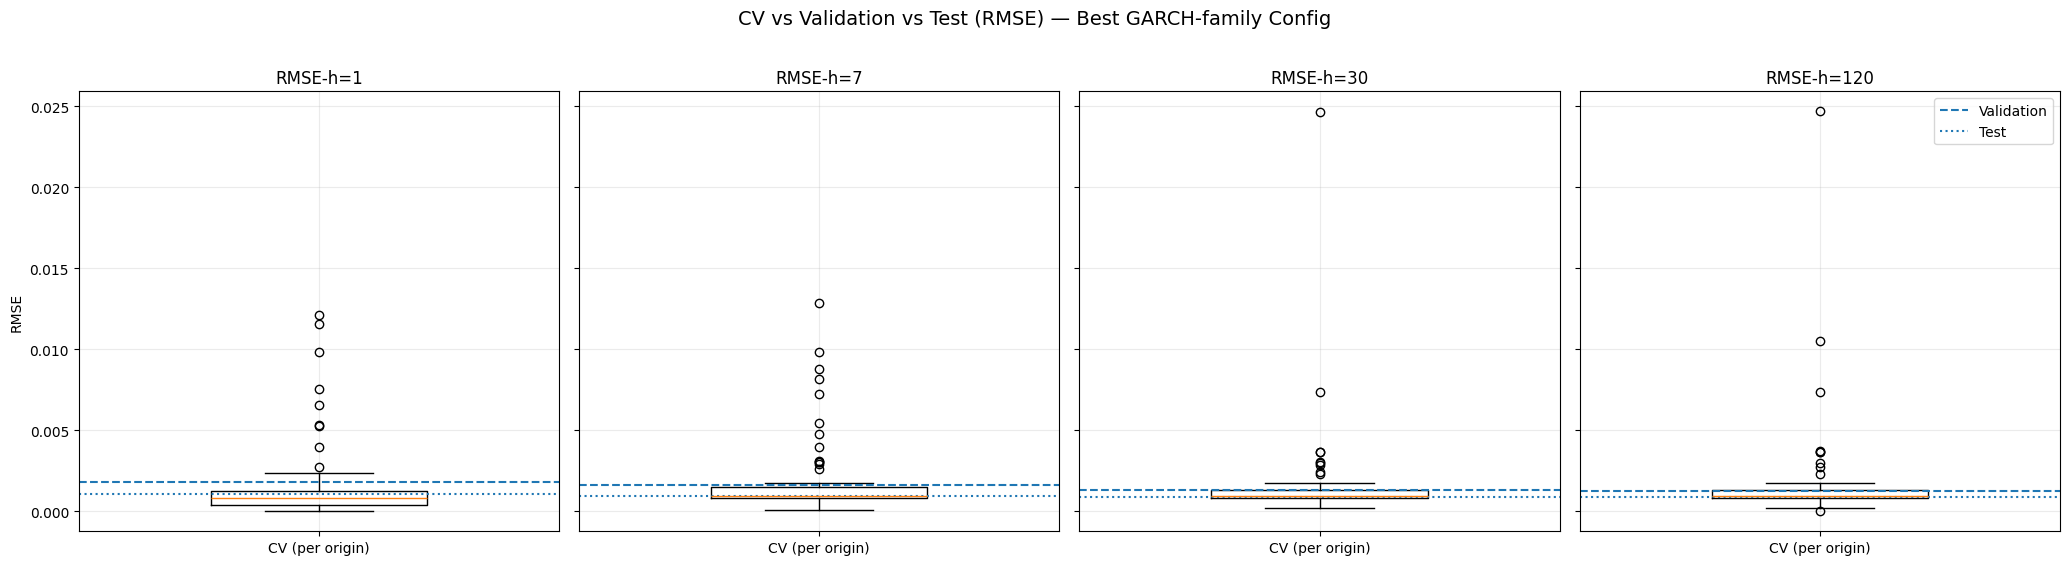

In [35]:
# Boxplots comparing CV distribution (per origin) vs Validation and Test RMSE
# for the selected best GARCH-family model across multiple horizons.
def match_col(df: pd.DataFrame, col: str, value):
    """Match df[col] to value, treating None as NaN."""
    if value is None:
        return df[col].isna()
    return df[col].eq(value)

def plot_cv_val_test_boxplots_multi(results_train: dict, results_validation: dict, results_test: dict,
                                    horizons: tuple[int, ...] = (1, 7, 30, 120)):
    """
    Plot CV distribution (per origin) vs Validation and Test RMSE for multiple horizons
    in a single figure with shared y-axis.
    """

    df_all = results_train["df_all_train"].copy()
    best_cfg = results_validation["best_config"]

    # Filter CV rows for the selected best GARCH-family config
    mask = (match_col(df_all, "model", best_cfg.model) &
            match_col(df_all, "mean", best_cfg.mean) &
            df_all["p"].eq(best_cfg.p) &
            df_all["o"].eq(best_cfg.o) &
            df_all["q"].eq(best_cfg.q) &
            match_col(df_all, "dist", best_cfg.dist))

    df_cv_best = df_all.loc[mask].copy()
    if df_cv_best.empty:
        raise ValueError("No CV rows found for best config in df_all_train.")

    horizons = tuple(sorted(set(int(h) for h in horizons)))

    # Prepare plot
    fig, axes = plt.subplots(1, len(horizons), figsize=(5.2 * len(horizons), 5.5), sharey=True)
    if len(horizons) == 1:
        axes = [axes]

    for ax, h in zip(axes, horizons):
        col = f"RMSE-h={h}"
        if col not in df_cv_best.columns:
            raise ValueError(f"{col} not found in CV results.")

        cv_values = df_cv_best[col].dropna().values
        val_value = float(results_validation["best_row"][col])
        test_value = float(results_test["test_results"].iloc[0][col])

        ax.boxplot(cv_values, vert=True, widths=0.45)
        ax.axhline(val_value, linestyle="--", label="Validation")
        ax.axhline(test_value, linestyle=":", label="Test")

        ax.set_title(f"RMSE-h={h}")
        ax.set_xticks([1])
        ax.set_xticklabels(["CV (per origin)"])
        ax.grid(alpha=0.25)

    axes[0].set_ylabel("RMSE")
    axes[-1].legend(loc="upper right")
    fig.suptitle("CV vs Validation vs Test (RMSE) — Best GARCH-family Config", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

plot_cv_val_test_boxplots_multi(results_train, results_validation, results_test, horizons=(1, 7, 30, 120))

In [36]:
# Calculate generalization gaps in percentage terms for each horizon and the average score.
def generalization_gaps_percent(results_train: dict, results_validation: dict, results_test: dict):

    best_cfg = results_validation["best_config"]
    df_train = results_train["summary_train"].copy()

    def match_col(df: pd.DataFrame, col: str, value):
        if value is None:
            return df[col].isna()
        return df[col].eq(value)

    mask = (match_col(df_train, "model", best_cfg.model) &
            match_col(df_train, "mean", best_cfg.mean) &
            df_train["p"].eq(best_cfg.p) &
            df_train["o"].eq(best_cfg.o) &
            df_train["q"].eq(best_cfg.q) &
            match_col(df_train, "dist", best_cfg.dist))

    df_train_best = df_train.loc[mask]
    if df_train_best.empty:
        raise ValueError("Best validation config not found in results_train['summary_train'].")

    train_row = df_train_best.iloc[0]
    val_row = results_validation["best_row"]
    test_row = results_test["test_results"].iloc[0]

    rmse_cols = sorted([c for c in test_row.index if str(c).startswith("RMSE-h=")],
                       key=lambda x: int(str(x).split("=")[1]))

    metric_cols = rmse_cols + (["score_rmse_mean"] if "score_rmse_mean" in test_row.index else [])

    def pct_gap(a, b):
        b = float(b)
        if b == 0:
            return np.nan
        return (float(a) - b) / b * 100.0

    rows = []
    for m in metric_cols:
        rows.append({"Metric": m,
                     "Val_vs_Train_%": pct_gap(val_row[m], train_row[m]),
                     "Test_vs_Train_%": pct_gap(test_row[m], train_row[m]),
                     "Test_vs_Val_%": pct_gap(test_row[m], val_row[m])})

    df = pd.DataFrame(rows)
    df = df.set_index("Metric").T

    return df

In [37]:
# Calculate and display generalization gaps in percentage terms
gap_df = generalization_gaps_percent(results_train=results_train,
                                     results_validation=results_validation,
                                     results_test=results_test)

display_table(gap_df, "Generalization Gaps (%)")


Generalization Gaps (%)
╒═════════════════╤══════════════╤══════════════╤══════════════╤══════════════╤══════════════╤═══════════════════╕
│                 │   RMSE-h=1   │   RMSE-h=7   │  RMSE-h=15   │  RMSE-h=30   │  RMSE-h=120  │   score_rmse_mean │
╞═════════════════╪══════════════╪══════════════╪══════════════╪══════════════╪══════════════╪═══════════════════╡
│ Val_vs_Train_%  │ 19.12998459  │ -3.36939611  │ -65.41703956 │ -10.99904505 │ -20.13597667 │      -29.41966143 │
├─────────────────┼──────────────┼──────────────┼──────────────┼──────────────┼──────────────┼───────────────────┤
│ Test_vs_Train_% │ -31.12045405 │ -46.34906172 │ -79.03507460 │ -40.31573682 │ -45.57279453 │      -56.77160890 │
├─────────────────┼──────────────┼──────────────┼──────────────┼──────────────┼──────────────┼───────────────────┤
│  Test_vs_Val_%  │ -42.18118454 │ -44.47831627 │ -39.37787530 │ -32.93974967 │ -31.85015831 │      -38.75292754 │
╘═════════════════╧══════════════╧══════════════╧══════

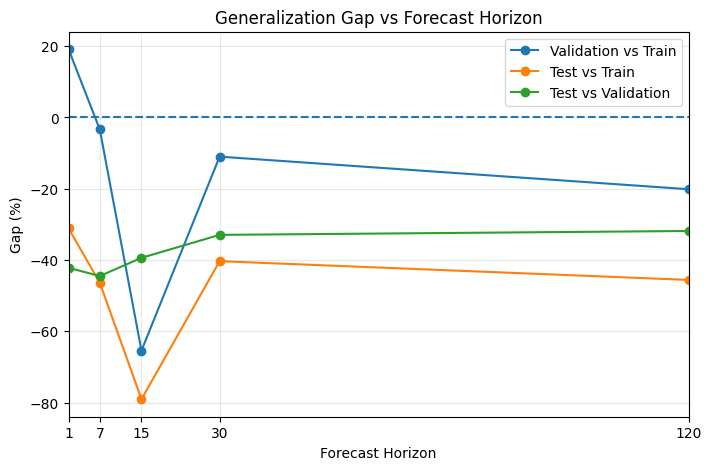

In [38]:
# Plot percentage generalization gaps vs forecast horizon.
df = gap_df.copy()

# Extract horizons from column names
horizons = [int(c.split("=")[1]) for c in df.columns if c.startswith("RMSE-h=")]

# Sort horizons
horizons = sorted(horizons)

val_train = [df.loc["Val_vs_Train_%", f"RMSE-h={h}"] for h in horizons]
test_train = [df.loc["Test_vs_Train_%", f"RMSE-h={h}"] for h in horizons]
test_val = [df.loc["Test_vs_Val_%", f"RMSE-h={h}"] for h in horizons]

plt.figure(figsize=(8,5))

plt.plot(horizons, val_train, marker="o", label="Validation vs Train")
plt.plot(horizons, test_train, marker="o", label="Test vs Train")
plt.plot(horizons, test_val, marker="o", label="Test vs Validation")

plt.axhline(0, linestyle="--")
plt.xticks(horizons)
plt.xlim(min(horizons), max(horizons))

plt.xlabel("Forecast Horizon")
plt.ylabel("Gap (%)")
plt.title("Generalization Gap vs Forecast Horizon")

plt.grid(alpha=0.3)
plt.legend()

plt.show()

---

# Comparação com o modelo Seasonal Naive

In [39]:
# Naive forecast implementation
def naive_forecast(y_train: pd.Series, h: int):
    """
    Naive forecast (lag-1 / persistence):
    y_hat(t+h) = y(t)
    for all h >= 1
    """

    if len(y_train) < 1:
        raise ValueError("Training series must contain at least one observation.")

    if h < 1:
        raise ValueError("Forecast horizon h must be >= 1.")

    last_value = float(y_train.iloc[-1])

    forecast = np.repeat(last_value, h)

    return forecast.astype(float)


# Seasonal naive forecast implementation
def seasonal_naive_forecast(y_train: pd.Series, h: int, m: int):
    """
    Seasonal naive forecast:
    y_hat(t+h) = y(t+h-m)
    """

    if h < 1:
        raise ValueError("Forecast horizon h must be >= 1.")

    if m is None or m < 2:
        raise ValueError("Seasonal period m must be >= 2 for seasonal naive forecast.")

    if len(y_train) < m:
        raise ValueError("Training series too short for seasonal naive.")

    last_season = y_train.iloc[-m:].values

    reps = int(np.ceil(h / m))
    forecast = np.tile(last_season, reps)[:h]

    return forecast.astype(float)

In [40]:
# Evaluate naive / seasonal naive on a single validation/test origin for ARCH-family pipeline
def arch_naive_evaluate_single_origin(r_train: pd.Series, r_eval: pd.Series, horizons: tuple[int, ...], m: Optional[int] = None, metric: str = "RMSE"):
    """
    Evaluate naive or seasonal naive benchmark for the ARCH-family pipeline.

    Notes
    -----
    - r_train is the return series available before the forecast origin.
    - r_eval contains the future return observations after the origin.
    - The naive benchmark is applied to the volatility proxy r_t².
    - This makes the benchmark comparable with ARCH-family conditional variance forecasts.
    """

    horizons = tuple(sorted(set(int(h) for h in horizons)))

    if len(horizons) == 0:
        raise ValueError("horizons cannot be empty.")

    if any(h <= 0 for h in horizons):
        raise ValueError("All horizons must be positive integers.")

    hmax = max(horizons)

    if len(r_eval) < hmax:
        raise ValueError(f"Evaluation set too short for hmax={hmax}. len(r_eval)={len(r_eval)}")

    metric = metric.upper()

    if metric not in ("RMSE", "MAPE", "SMAPE", "QLIKE"):
        raise ValueError("metric must be one of: 'RMSE', 'MAPE', 'SMAPE', 'QLIKE'.")

    # Convert returns to volatility proxy
    v_train = r_train.astype(float).pow(2).replace([np.inf, -np.inf], np.nan).dropna().copy()
    v_eval = r_eval.astype(float).pow(2).replace([np.inf, -np.inf], np.nan).dropna().copy()

    if len(v_train) < 1:
        raise ValueError("Training volatility proxy is empty after preprocessing.")

    if len(v_eval) < hmax:
        raise ValueError(f"Evaluation volatility proxy too short for hmax={hmax}. len(v_eval)={len(v_eval)}")

    if m is None:
        y_hat = naive_forecast(y_train=v_train, h=hmax)
        row = {"model": "naive", "variant": "naive", "m": None}

    else:
        y_hat = seasonal_naive_forecast(y_train=v_train, h=hmax, m=m)
        row = {"model": "naive", "variant": f"seasonal_naive(m={m})", "m": m}

    y_hat = np.asarray(y_hat, dtype=float)
    y_eval_hmax = v_eval.iloc[:hmax].values.astype(float)

    rmse_list = []
    mape_list = []
    smape_list = []
    qlike_list = []

    forecast_rows = []

    for h in horizons:
        # Point-specific horizon evaluation, matching ARIMA logic
        y_true = np.asarray([y_eval_hmax[h - 1]], dtype=float)
        y_pred = np.asarray([y_hat[h - 1]], dtype=float)

        row[f"RMSE-h={h}"] = rmse(y_true, y_pred)
        row[f"MAPE-h={h}"], row[f"SMAPE-h={h}"] = mape_smape(y_true, y_pred)
        row[f"QLIKE-h={h}"] = qlike(y_true, y_pred)

        rmse_list.append(row[f"RMSE-h={h}"])
        mape_list.append(row[f"MAPE-h={h}"])
        smape_list.append(row[f"SMAPE-h={h}"])
        qlike_list.append(row[f"QLIKE-h={h}"])

        y_true_h = float(y_eval_hmax[h - 1])
        y_pred_h = float(y_hat[h - 1])

        forecast_rows.append({"model": "naive",
                              "variant": row["variant"],
                              "m": m,
                              "horizon": int(h),
                              "y_true_vol_proxy": y_true_h,
                              "forecast": y_pred_h,
                              "residual": y_true_h - y_pred_h})

    row["score_rmse_mean"] = float(np.nanmean(rmse_list))
    row["score_mape_mean"] = float(np.nanmean(mape_list))
    row["score_smape_mean"] = float(np.nanmean(smape_list))
    row["score_qlike_mean"] = float(np.nanmean(qlike_list))

    if metric == "RMSE":
        row["score_selected"] = row["score_rmse_mean"]
    elif metric == "MAPE":
        row["score_selected"] = row["score_mape_mean"]
    elif metric == "SMAPE":
        row["score_selected"] = row["score_smape_mean"]
    elif metric == "QLIKE":
        row["score_selected"] = row["score_qlike_mean"]

    row["valid"] = True

    df_forecasts = pd.DataFrame(forecast_rows)

    return row, df_forecasts

In [41]:
# Evaluate naive / seasonal naive using rolling/expanding origins for ARCH-family pipeline
def arch_naive_evaluate_rolling(r_train: pd.Series, r_eval: pd.Series, horizons: tuple[int, ...], m: Optional[int] = None, metric: str = "RMSE", mode: BacktestMode = "rolling",
                                step: int = 1, window: Optional[int] = None, stage_name: str = "evaluation"):
    """
    Evaluate naive or seasonal naive benchmark using rolling/expanding origins
    for the ARCH-family pipeline.

    Parameters
    ----------
    r_train (pd.Series): Historical return series before the evaluation period.

    r_eval (pd.Series): Validation or test return series.

    horizons (tuple[int, ...]): Forecast horizons to evaluate.

    m (Optional[int]): Seasonal period for seasonal naive. If None, use non-seasonal naive.

    metric (str): Metric to use for scoring ("RMSE", "MAPE", "SMAPE", "QLIKE").

    mode (BacktestMode): "rolling", "expanding", or "none".

    step (int): Step size between forecast origins.

    window (Optional[int]): Window size for rolling origins.

    stage_name (str): Name used only for progress display.

    Notes
    -----
    - The benchmark is applied to the volatility proxy r_t².
    - This makes it comparable with ARCH-family conditional variance forecasts.
    """

    horizons = tuple(sorted(set(int(h) for h in horizons)))

    if len(horizons) == 0:
        raise ValueError("horizons cannot be empty.")

    if any(h <= 0 for h in horizons):
        raise ValueError("All horizons must be positive integers.")

    metric = metric.upper()

    if metric not in ("RMSE", "MAPE", "SMAPE", "QLIKE"):
        raise ValueError("metric must be one of: 'RMSE', 'MAPE', 'SMAPE', 'QLIKE'.")

    blocks = generate_evaluation_backtest_blocks(y_train=r_train,
                                                 y_val=r_eval,
                                                 horizons=horizons,
                                                 mode=mode,
                                                 window=window,
                                                 step=step)

    r_full = pd.concat([r_train, r_eval]).copy()

    rows = []
    forecast_frames = []

    for b in tqdm(blocks, desc=f"Naive {stage_name} - origins", unit="origin"):

        try:
            origin_date = r_full.index[b.origin]
        except Exception:
            origin_date = None

        try:
            out, df_forecast = arch_naive_evaluate_single_origin(r_train=b.train, r_eval=b.test, horizons=horizons, m=m, metric=metric)

            if out.get("valid", False):
                out["origin"] = b.origin
                out["origin_date"] = origin_date
                rows.append(out)

                if not df_forecast.empty:
                    df_forecast["origin"] = b.origin
                    df_forecast["origin_date"] = origin_date
                    forecast_frames.append(df_forecast)

        except Exception:
            # Keep robust behaviour, but do not stop the full evaluation
            continue

    df_by_origin = pd.DataFrame(rows)

    df_forecasts = (pd.concat(forecast_frames, ignore_index=True) if len(forecast_frames) else pd.DataFrame())

    if df_by_origin.empty:
        raise ValueError("No valid naive origins could be evaluated.")

    group_cols = ["model", "variant", "m"]

    rmse_cols = sorted([c for c in df_by_origin.columns if c.startswith("RMSE-h=")], key=lambda x: int(x.split("=")[1]))
    mape_cols = sorted([c for c in df_by_origin.columns if c.startswith("MAPE-h=")], key=lambda x: int(x.split("=")[1]))
    smape_cols = sorted([c for c in df_by_origin.columns if c.startswith("SMAPE-h=")], key=lambda x: int(x.split("=")[1]))
    qlike_cols = sorted([c for c in df_by_origin.columns if c.startswith("QLIKE-h=")], key=lambda x: int(x.split("=")[1]))

    metric_cols = (rmse_cols + mape_cols + smape_cols + qlike_cols + ["score_rmse_mean", "score_mape_mean", "score_smape_mean", "score_qlike_mean", "score_selected"])

    metric_cols = [c for c in metric_cols if c in df_by_origin.columns]

    df_results = (df_by_origin.groupby(group_cols, dropna=False)[metric_cols].mean().sort_values("score_selected", ascending=True).reset_index())

    id_cols = ["model", "variant", "m"]

    score_cols = ["score_rmse_mean", "score_mape_mean", "score_smape_mean", "score_qlike_mean", "score_selected"]

    ordered_cols = (id_cols + rmse_cols + mape_cols + smape_cols + qlike_cols + score_cols)

    ordered_cols = [c for c in ordered_cols if c in df_results.columns]

    df_results = df_results[ordered_cols].copy()

    return {"results": df_results,
            "results_by_origin": df_by_origin,
            "df_forecasts": df_forecasts,
            "blocks_n": len(blocks),
            "hmax": max(horizons),
            "model": "naive",
            "variant": "naive" if m is None else f"seasonal_naive(m={m})",
            "m": m}

In [42]:
# Caching mechanism for ARCH-family Naive rolling/expanding test results
def run_or_load_arch_naive_test(cache_dir: str, cache_name: str, y_train: pd.Series, y_val: pd.Series, y_test: pd.Series, horizons: tuple[int, ...], m: Optional[int] = None,
                                metric: str = "RMSE", mode: BacktestMode = "rolling", step: int = 1, window: Optional[int] = None):
    """
    Run or load final Naive test evaluation using rolling/expanding test origins
    for the ARCH-family pipeline.

    Cache files
    -----------
    - meta.json
    - test_results.parquet
    - test_results_by_origin.parquet
    - forecasts.parquet

    Notes
    -----
    - y_train, y_val and y_test must be return series.
    - Uses y_dev = y_train + y_val as historical information before the test period.
    - The Naive benchmark is applied internally to the volatility proxy r_t².
    - Forecasts and observations are stored on the original volatility-proxy scale.
    """

    def series_signature(y: pd.Series):
        """
        Create a simple signature for a Series based on values and index.
        """
        hashed = pd.util.hash_pandas_object(y, index=True).values.tobytes()
        return hashlib.sha256(hashed).hexdigest()

    metric = metric.upper()

    if metric not in ("RMSE", "MAPE", "SMAPE", "QLIKE"):
        raise ValueError("metric must be one of: 'RMSE', 'MAPE', 'SMAPE', 'QLIKE'.")

    cache_path = Path(cache_dir) / cache_name
    cache_path.mkdir(parents=True, exist_ok=True)

    meta_file = cache_path / "meta.json"
    test_file = cache_path / "test_results.parquet"
    test_by_origin_file = cache_path / "test_results_by_origin.parquet"
    forecasts_file = cache_path / "forecasts.parquet"

    expected_meta = {"horizons": list(sorted(set(int(h) for h in horizons))),
                     "mode": mode,
                     "step": step,
                     "window": int(window) if window is not None else None,
                     "m": int(m) if m is not None else None,
                     "metric": metric,
                     "model": "naive",
                     "variant": "naive" if m is None else f"seasonal_naive(m={m})",
                     "stored_forecasts": True,
                     "forecast_scale": "original_volatility_proxy",
                     "input_series": "returns",
                     "evaluation_target": "squared_returns",
                     "test_type": "rolling_expanding_origins",
                     "y_train_signature": series_signature(y_train),
                     "y_train_length": len(y_train),
                     "y_train_start": str(y_train.index.min()),
                     "y_train_end": str(y_train.index.max()),
                     "y_val_signature": series_signature(y_val),
                     "y_val_length": len(y_val),
                     "y_val_start": str(y_val.index.min()),
                     "y_val_end": str(y_val.index.max()),
                     "y_test_signature": series_signature(y_test),
                     "y_test_length": len(y_test),
                     "y_test_start": str(y_test.index.min()),
                     "y_test_end": str(y_test.index.max())}

    required_files_exist = (meta_file.exists() and test_file.exists() and test_by_origin_file.exists() and forecasts_file.exists())

    # Load only if cache exists and metadata matches current input
    if required_files_exist:
        meta = json.loads(meta_file.read_text(encoding="utf-8"))

        cache_is_valid = (meta.get("horizons") == expected_meta["horizons"]
                          and meta.get("mode") == expected_meta["mode"]
                          and meta.get("step") == expected_meta["step"]
                          and meta.get("window") == expected_meta["window"]
                          and meta.get("m") == expected_meta["m"]
                          and meta.get("metric") == expected_meta["metric"]
                          and meta.get("model") == expected_meta["model"]
                          and meta.get("variant") == expected_meta["variant"]
                          and meta.get("stored_forecasts") == expected_meta["stored_forecasts"]
                          and meta.get("forecast_scale") == expected_meta["forecast_scale"]
                          and meta.get("input_series") == expected_meta["input_series"]
                          and meta.get("evaluation_target") == expected_meta["evaluation_target"]
                          and meta.get("test_type") == expected_meta["test_type"]
                          and meta.get("y_train_signature") == expected_meta["y_train_signature"]
                          and meta.get("y_train_length") == expected_meta["y_train_length"]
                          and meta.get("y_train_start") == expected_meta["y_train_start"]
                          and meta.get("y_train_end") == expected_meta["y_train_end"]
                          and meta.get("y_val_signature") == expected_meta["y_val_signature"]
                          and meta.get("y_val_length") == expected_meta["y_val_length"]
                          and meta.get("y_val_start") == expected_meta["y_val_start"]
                          and meta.get("y_val_end") == expected_meta["y_val_end"]
                          and meta.get("y_test_signature") == expected_meta["y_test_signature"]
                          and meta.get("y_test_length") == expected_meta["y_test_length"]
                          and meta.get("y_test_start") == expected_meta["y_test_start"]
                          and meta.get("y_test_end") == expected_meta["y_test_end"])

        if cache_is_valid:
            df_test = pd.read_parquet(test_file)
            df_test_by_origin = pd.read_parquet(test_by_origin_file)
            df_forecasts_test = pd.read_parquet(forecasts_file)

            return {"results": df_test,
                    "results_by_origin": df_test_by_origin,
                    "df_forecasts": df_forecasts_test,
                    "blocks_n": meta.get("blocks_n"),
                    "hmax": meta.get("hmax"),
                    "model": "naive",
                    "variant": expected_meta["variant"],
                    "m": m,
                    "forecast": df_forecasts_test["forecast"].to_numpy(dtype=float) if "forecast" in df_forecasts_test.columns else np.array([]),
                    "y_true": df_forecasts_test["y_true_vol_proxy"].to_numpy(dtype=float) if "y_true_vol_proxy" in df_forecasts_test.columns else np.array([]),
                    "meta": meta}

        print("Warning: cache metadata does not match current ARCH-family Naive test input. Recomputing Naive test.")

    # Otherwise run rolling/expanding test evaluation
    y_dev = pd.concat([y_train, y_val]).copy()

    out = arch_naive_evaluate_rolling(r_train=y_dev,
                                      r_eval=y_test,
                                      horizons=horizons,
                                      m=m,
                                      metric=metric,
                                      mode=mode,
                                      step=step,
                                      window=window,
                                      stage_name="test")

    meta = {**expected_meta,
            "hmax": int(out.get("hmax", max(horizons))),
            "y_dev_len": int(len(y_dev)),
            "blocks_n": int(out.get("blocks_n", 0))}

    meta_file.write_text(json.dumps(meta, indent=2), encoding="utf-8")

    out["results"].to_parquet(test_file, index=False)
    out["results_by_origin"].to_parquet(test_by_origin_file, index=False)
    out["df_forecasts"].to_parquet(forecasts_file, index=False)

    out["meta"] = meta

    return out

In [43]:
# Evaluate naive benchmark on test set using rolling/expanding origins
cache_dir = r"D:\Hnsx\Formação Superior\0_Universidade Europeia\Mestrado em Ciência de Dados e Análise de Negócios\Curso\Tese_DataScience\Código\Tese_ARCH_results"

cache_name_naive_test = (f"Tese_Bitcoin_{serie_cache_name}_ARCH_NAIVE_test_{mode}_step{step}_h{max(horizons)}_pkl")

results_naive_test = run_or_load_arch_naive_test(cache_dir=cache_dir,
                                                 cache_name=cache_name_naive_test,
                                                 y_train=y_train,
                                                 y_val=y_val,
                                                 y_test=y_test,
                                                 horizons=horizons,
                                                 m=None,
                                                 metric="RMSE",
                                                 mode=mode,
                                                 step=step,
                                                 window=None)

df_naive_test = results_naive_test["results"].copy()

display_table(df_naive_test, "Naive model for ARCH-family pipeline (rolling test):")


Naive model for ARCH-family pipeline (rolling test):
╒════╤═════════╤═══════════╤═════╤════════════╤════════════╤═════════════╤═════════════╤══════════════╤═════════════════╤══════════════════╤════════════════╤═══════════════╤════════════════╤══════════════╤══════════════╤══════════════╤══════════════╤═══════════════╤══════════════╤══════════════╤══════════════╤══════════════╤═══════════════╤═══════════════════╤═══════════════════╤════════════════════╤════════════════════╤══════════════════╕
│    │  model  │  variant  │  m  │  RMSE-h=1  │  RMSE-h=7  │  RMSE-h=15  │  RMSE-h=30  │  RMSE-h=120  │    MAPE-h=1     │     MAPE-h=7     │   MAPE-h=15    │   MAPE-h=30   │   MAPE-h=120   │  SMAPE-h=1   │  SMAPE-h=7   │  SMAPE-h=15  │  SMAPE-h=30  │  SMAPE-h=120  │  QLIKE-h=1   │  QLIKE-h=7   │  QLIKE-h=15  │  QLIKE-h=30  │  QLIKE-h=120  │  score_rmse_mean  │  score_mape_mean  │  score_smape_mean  │  score_qlike_mean  │   score_selected │
╞════╪═════════╪═══════════╪═════╪════════════╪═══════════

In [44]:
# Compare ARCH-family model against Naive benchmark on the test set

df_arch_test = results_test["test_results"].copy()
df_naive_results = df_naive_test.copy()

# Combine ARCH-family model and Naive benchmark
df_compare = pd.concat([df_arch_test, df_naive_results], ignore_index=True, sort=False)

# Format p, o, q and m without decimal places
for col in ["p", "o", "q", "m"]:
    if col in df_compare.columns:
        df_compare[col] = df_compare[col].apply(lambda x: "-" if pd.isna(x) else str(int(x)))

# Replace missing descriptive fields with "-"
for col in ["mean", "dist", "variant"]:
    if col in df_compare.columns:
        df_compare[col] = df_compare[col].fillna("-")

# Remove sMAPE columns only for presentation
smape_cols = [c for c in df_compare.columns if c.startswith("SMAPE-h=")]

df_compare_show = df_compare.drop(columns=smape_cols, errors="ignore")

display_table(df_compare_show, "ARCH-family model vs Naive benchmark (test):")


ARCH-family model vs Naive benchmark (test):
╒════╤═════════╤════════╤═════╤═════╤═════╤════════╤════════════╤════════════╤═════════════╤═════════════╤══════════════╤═════════════════╤═══════════════════╤════════════════╤════════════════╤════════════════╤══════════════╤══════════════╤══════════════╤══════════════╤═══════════════╤═══════════════════╤═══════════════════╤════════════════════╤════════════════════╤══════════════════╤═══════════╤═════╕
│    │  model  │  mean  │  p  │  o  │  q  │  dist  │  RMSE-h=1  │  RMSE-h=7  │  RMSE-h=15  │  RMSE-h=30  │  RMSE-h=120  │    MAPE-h=1     │     MAPE-h=7      │   MAPE-h=15    │   MAPE-h=30    │   MAPE-h=120   │  QLIKE-h=1   │  QLIKE-h=7   │  QLIKE-h=15  │  QLIKE-h=30  │  QLIKE-h=120  │  score_rmse_mean  │  score_mape_mean  │  score_smape_mean  │  score_qlike_mean  │  score_selected  │  variant  │ m   │
╞════╪═════════╪════════╪═════╪═════╪═════╪════════╪════════════╪════════════╪═════════════╪═════════════╪══════════════╪═════════════════╪═══

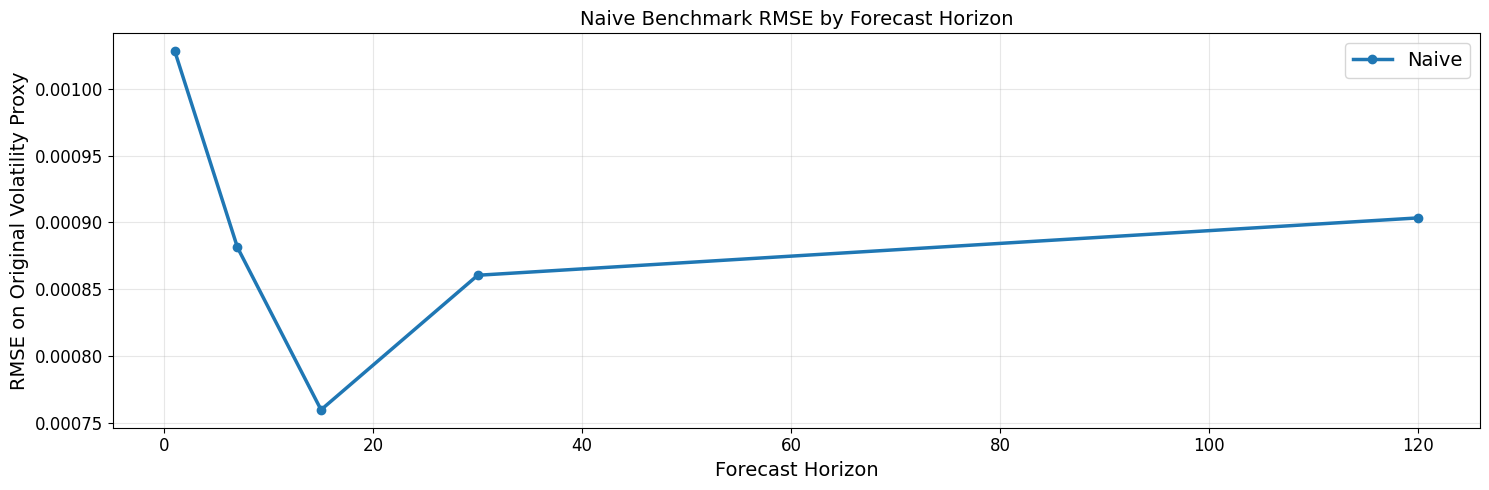

In [45]:
# Plot Naive benchmark RMSE across forecast horizons
def plot_naive_rmse_vs_horizon(df_naive: pd.DataFrame):
    """
    Plot RMSE vs forecast horizon for the Naive benchmark.
    Assumes RMSE values were computed on the original volatility-proxy scale.
    """

    # Identify RMSE columns
    rmse_cols = sorted([c for c in df_naive.columns if c.startswith("RMSE-h=")], key=lambda x: int(x.split("=")[1]))

    horizons = [int(c.split("=")[1]) for c in rmse_cols]

    # Select Naive row
    if "model" in df_naive.columns:
        naive_row = df_naive[df_naive["model"].astype(str).str.lower().eq("naive")].iloc[0]
    else:
        naive_row = df_naive.iloc[0]

    naive_rmse = naive_row[rmse_cols].astype(float).values

    plt.figure(figsize=(15, 5))

    plt.plot(horizons, naive_rmse, marker="o", linewidth=2.5, label="Naive")

    plt.title("Naive Benchmark RMSE by Forecast Horizon", fontsize=14)
    plt.xlabel("Forecast Horizon", fontsize=14)
    plt.xticks(fontsize=12)
    plt.ylabel("RMSE on Original Volatility Proxy", fontsize=14)
    plt.yticks(fontsize=12)

    plt.legend(fontsize=14)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_naive_rmse_vs_horizon(results_naive_test["results"])

---

# Análise de Resíduos

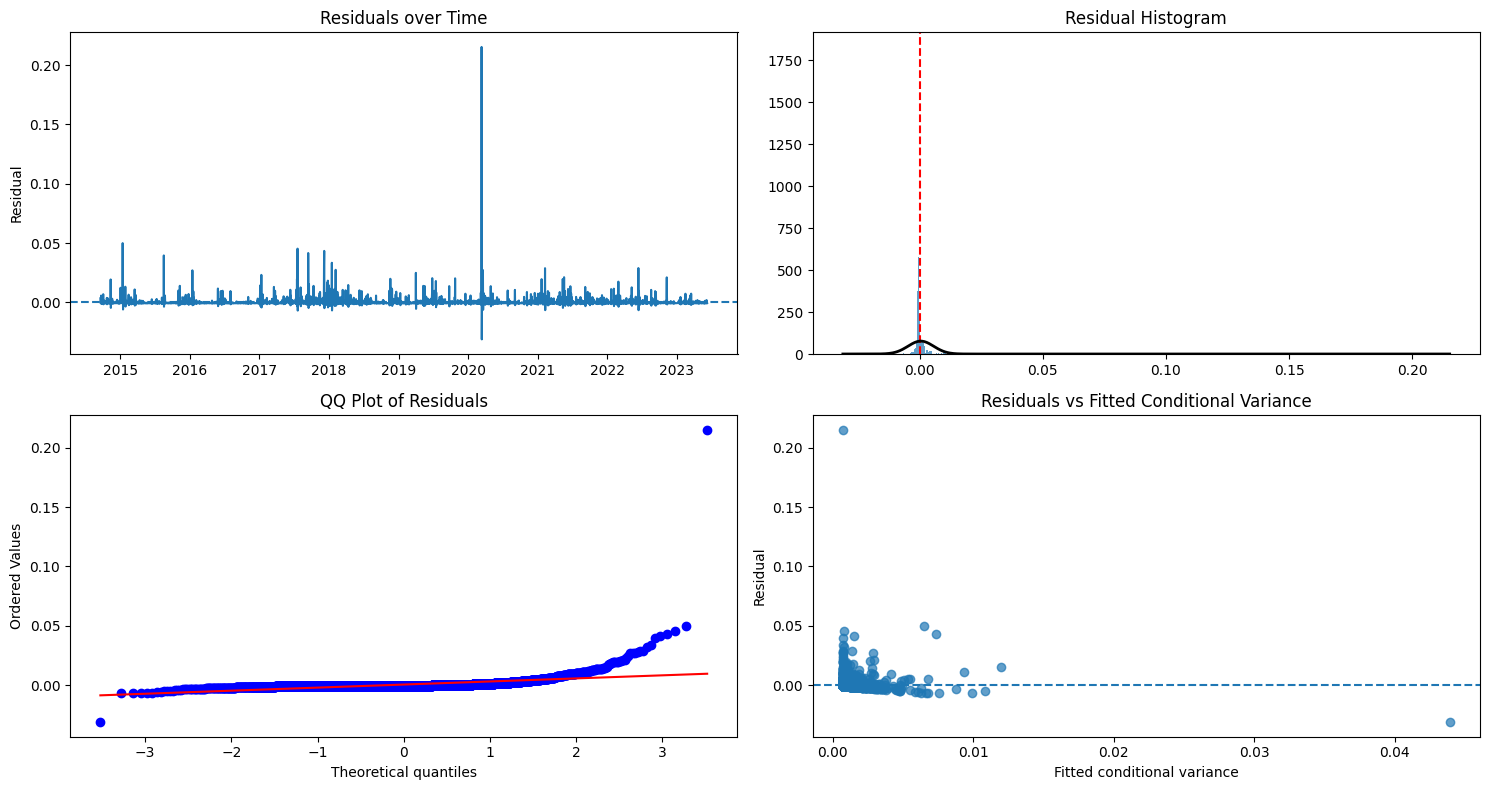

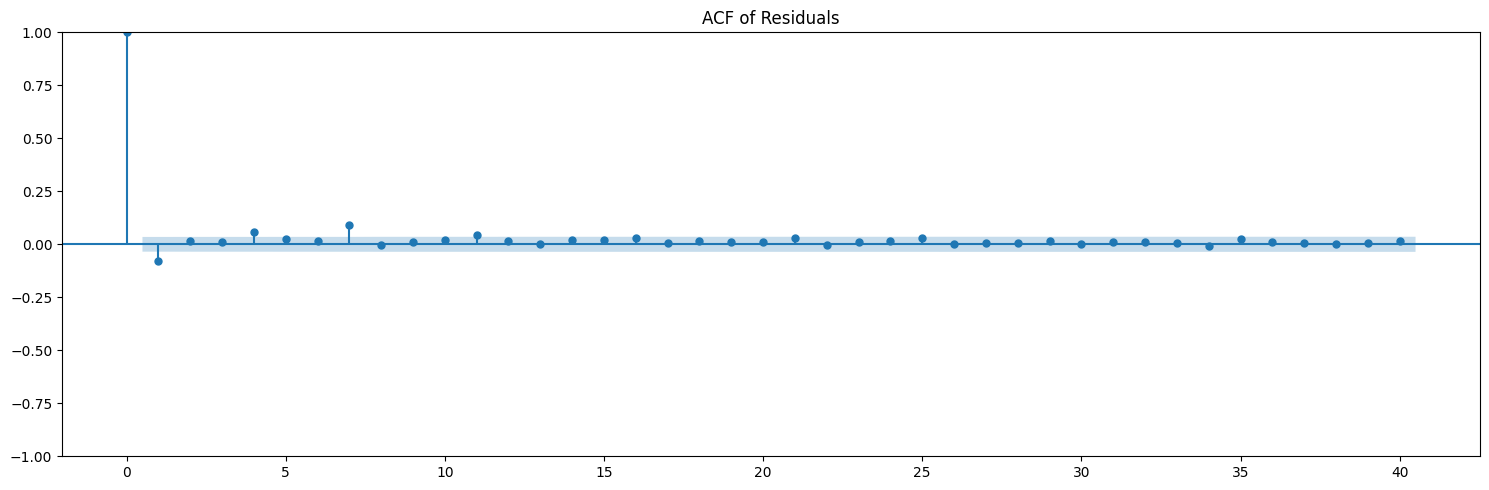


Residual Diagnostics - Final ARCH-family Model - Original Scale
╒════╤════════════════════════════╤══════════════╕
│    │           Metric           │        Value │
╞════╪════════════════════════════╪══════════════╡
│ 0  │            Mean            │   0.00043478 │
├────┼────────────────────────────┼──────────────┤
│ 1  │           Median           │  -0.00061514 │
├────┼────────────────────────────┼──────────────┤
│ 2  │            Std             │   0.00518770 │
├────┼────────────────────────────┼──────────────┤
│ 3  │          Skewness          │  24.10016260 │
├────┼────────────────────────────┼──────────────┤
│ 4  │          Kurtosis          │ 934.28277928 │
├────┼────────────────────────────┼──────────────┤
│ 5  │        KS Statistic        │   0.31078376 │
├────┼────────────────────────────┼──────────────┤
│ 6  │         KS p-value         │   0.00000000 │
├────┼────────────────────────────┼──────────────┤
│ 7  │ Ljung-Box p-value (lag=20) │   0.00000002 │
╘════╧═══════════

In [46]:
# Final ARCH-family model fitting and residual diagnostics
def fit_final_arch_model(y_train: pd.Series, y_val: pd.Series, cfg: GARCHConfig, residual_scale: str = "original"):
    """
    Fit the final ARCH-family model on the development set (train + validation).

    Notes
    -----
    - y_train and y_val must be return series.
    - The model is fitted on returns.
    - Fitted values are conditional variance estimates sigma_t².
    - Residuals are computed as r_t² - sigma_t².

    Returns
    -------
    dict with:
    - y_dev
    - y_dev_used
    - model
    - fit
    - fitted_values
    - residuals
    """

    if residual_scale not in ("original", "model"):
        raise ValueError("residual_scale must be either 'original' or 'model'.")

    y_dev = pd.concat([y_train, y_val]).copy()
    y_dev = y_dev.astype(float).replace([np.inf, -np.inf], np.nan).dropna()

    if not is_arch_config_compatible(y_dev, cfg):
        raise ValueError(f"Selected config is not compatible with y_dev: {cfg.to_label()}")

    # Map model label to arch package volatility specification
    if cfg.model == "ARCH":
        vol = "GARCH"
        p, o, q = cfg.p, 0, 0

    elif cfg.model == "GARCH":
        vol = "GARCH"
        p, o, q = cfg.p, 0, cfg.q

    elif cfg.model == "GJR-GARCH":
        vol = "GARCH"
        p, o, q = cfg.p, cfg.o, cfg.q

    elif cfg.model == "EGARCH":
        vol = "EGARCH"
        p, o, q = cfg.p, cfg.o, cfg.q

    else:
        raise ValueError(f"Unsupported ARCH-family model: {cfg.model}")

    model = arch_model(y_dev, mean=cfg.mean, vol=vol, p=p, o=o, q=q, dist=cfg.dist)

    fit = model.fit(disp="off", show_warning=False)

    # Observed volatility proxy
    y_dev_proxy = y_dev.pow(2).rename("observed_vol_proxy")

    # Fitted conditional variance sigma_t²
    fitted_variance = pd.Series(fit.conditional_volatility ** 2, index=y_dev.index, name="fitted")

    # Residuals in variance/proxy scale: r_t² - sigma_t²
    residuals_variance_scale = pd.Series(y_dev_proxy.values - fitted_variance.values, index=y_dev.index, name="residuals")

    # Remove initial observations affected by model initialization
    burn_in = max(cfg.p, cfg.o, cfg.q)

    if burn_in > 0:
        y_dev_used = y_dev.iloc[burn_in:].copy()
        fitted_variance = fitted_variance.iloc[burn_in:].copy()
        residuals_variance_scale = residuals_variance_scale.iloc[burn_in:].copy()
    else:
        y_dev_used = y_dev.copy()

    if residual_scale == "model":
        # Standard model residuals are return residuals from the mean equation.
        # This is useful as an auxiliary diagnostic, but it is not the main
        # volatility-proxy residual used for model comparison.
        residuals_model_scale = pd.Series(fit.resid,
                                          index=y_dev.index,
                                          name="residuals")

        if burn_in > 0:
            residuals_model_scale = residuals_model_scale.iloc[burn_in:].copy()

        fitted_values = fitted_variance.rename("fitted")
        residuals = residuals_model_scale.rename("residuals")

    else:
        fitted_values = fitted_variance.rename("fitted")
        residuals = residuals_variance_scale.rename("residuals")

    return {"y_dev": y_dev,
            "y_dev_used": y_dev_used,
            "model": model,
            "fit": fit,
            "fitted_values": fitted_values,
            "residuals": residuals,
            "residual_scale": residual_scale}

def arch_residual_diagnostics_table(residuals: pd.Series, ljung_box_lags: int = 20):
    """
    Compute a compact residual diagnostics table for ARCH-family residuals.
    """
    
    residuals = residuals.dropna().copy()

    lb = acorr_ljungbox(residuals, lags=[ljung_box_lags], return_df=True)

    ks_stat, ks_pvalue = kstest( residuals.values, "norm", args=(float(residuals.mean()), float(residuals.std(ddof=0)))    )

    out = pd.DataFrame({"Metric": ["Mean",
                                   "Median",
                                   "Std",
                                   "Skewness",
                                   "Kurtosis",
                                   "KS Statistic",
                                   "KS p-value",
                                   f"Ljung-Box p-value (lag={ljung_box_lags})"],

                        "Value": [float(residuals.mean()),
                                  float(residuals.median()),
                                  float(residuals.std()),
                                  float(residuals.skew()),
                                  float(residuals.kurtosis()),
                                  float(ks_stat),
                                  float(ks_pvalue),
                                  float(lb["lb_pvalue"].iloc[0])]})

    return out

def plot_arch_residual_diagnostics(residuals: pd.Series, fitted_values: pd.Series, acf_lags: int = 40):
    """
    Plot standard residual diagnostics for the final ARCH-family model.
    """
    
    residuals = residuals.dropna().copy()

    fig, axes = plt.subplots(2, 2, figsize=(15, 8))

    # Residual time plot
    axes[0, 0].plot(residuals.index, residuals.values)
    axes[0, 0].axhline(0, linestyle="--")
    axes[0, 0].set_title("Residuals over Time")
    axes[0, 0].set_ylabel("Residual")

    # Histogram with Freedman-Diaconis bins
    n_bins, _ = freedman_diaconis_bins(residuals.values)
    axes[0, 1].hist(residuals.values, bins=n_bins, density=True, alpha=0.7)
    axes[0, 1].axvline(0, linestyle="--", color="red")

    x = np.linspace(residuals.min(), residuals.max(), 500)
    axes[0, 1].plot(x, norm.pdf(x, residuals.mean(), residuals.std()), linewidth=2, color="black")
    axes[0, 1].set_title("Residual Histogram")

    # QQ plot
    stats.probplot(residuals.values, dist="norm", plot=axes[1, 0])
    axes[1, 0].set_title("QQ Plot of Residuals")

    # Residuals vs fitted conditional variance
    fitted_aligned = fitted_values.loc[residuals.index]

    axes[1, 1].scatter(fitted_aligned, residuals.values, alpha=0.7)
    axes[1, 1].axhline(0, linestyle="--")
    axes[1, 1].set_title("Residuals vs Fitted Conditional Variance")
    axes[1, 1].set_xlabel("Fitted conditional variance")
    axes[1, 1].set_ylabel("Residual")

    plt.tight_layout()
    plt.show()

    # ACF plot in a separate figure
    fig, ax = plt.subplots(figsize=(15, 5))
    plot_acf(residuals, lags=acf_lags, ax=ax)
    ax.set_title("ACF of Residuals")
    plt.tight_layout()
    plt.show()

def run_final_arch_residual_diagnostics(y_train: pd.Series, y_val: pd.Series, cfg: GARCHConfig, ljung_box_lags: int = 20, acf_lags: int = 40, residual_scale: str = "original"):
    """
    Full residual diagnostics workflow for the final ARCH-family model.

    Notes
    -----
    - y_train and y_val must be return series.
    - If residual_scale="original", residuals are computed as r_t² - sigma_t².
    - If residual_scale="model", residuals are return residuals from the mean equation.
    """

    fit_pack = fit_final_arch_model(y_train=y_train, y_val=y_val, cfg=cfg, residual_scale=residual_scale)

    diag_table = arch_residual_diagnostics_table(residuals=fit_pack["residuals"], ljung_box_lags=ljung_box_lags)

    plot_arch_residual_diagnostics(residuals=fit_pack["residuals"], fitted_values=fit_pack["fitted_values"], acf_lags=acf_lags)

    return {"y_dev": fit_pack["y_dev"],
            "y_dev_used": fit_pack["y_dev_used"],
            "fit": fit_pack["fit"],
            "fitted_values": fit_pack["fitted_values"],
            "residuals": fit_pack["residuals"],
            "residual_scale": fit_pack["residual_scale"],
            "diagnostics_table": diag_table}

best_cfg = results_validation["best_config"]

residual_pack = run_final_arch_residual_diagnostics(y_train=y_train,
                                                    y_val=y_val,
                                                    cfg=best_cfg,
                                                    ljung_box_lags=20,
                                                    acf_lags=40,
                                                    residual_scale="original")

display_table(residual_pack["diagnostics_table"], "Residual Diagnostics - Final ARCH-family Model - Original Scale")

---

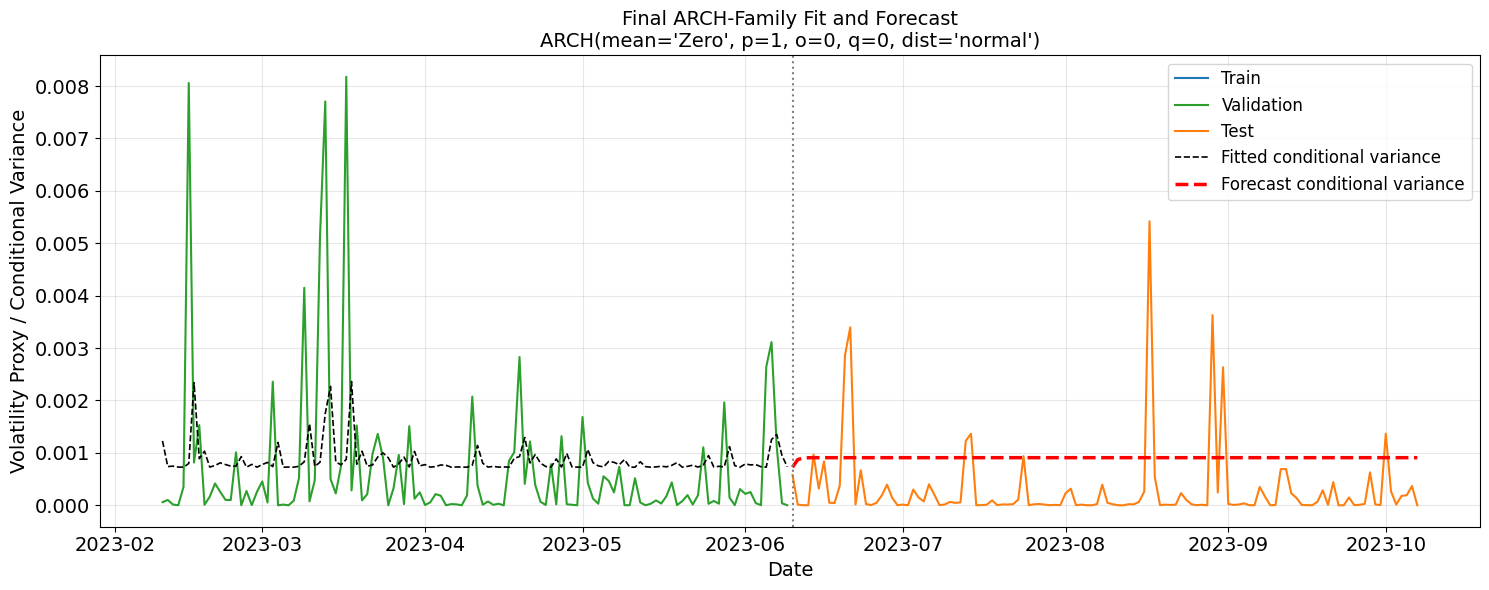

In [47]:
# Fit final ARCH-family model on y_dev and plot fitted conditional variance + forecast vs observed volatility proxy
y_dev = pd.concat([y_train, y_val]).copy()
y_dev = y_dev.astype(float).replace([np.inf, -np.inf], np.nan).dropna()

window = 120

# Map selected ARCH-family configuration to arch package specification
if best_cfg.model == "ARCH":
    vol = "GARCH"
    p, o, q = best_cfg.p, 0, 0
    forecast_method = "analytic"

elif best_cfg.model == "GARCH":
    vol = "GARCH"
    p, o, q = best_cfg.p, 0, best_cfg.q
    forecast_method = "analytic"

elif best_cfg.model == "GJR-GARCH":
    vol = "GARCH"
    p, o, q = best_cfg.p, best_cfg.o, best_cfg.q
    forecast_method = "analytic" if window == 1 else "simulation"

elif best_cfg.model == "EGARCH":
    vol = "EGARCH"
    p, o, q = best_cfg.p, best_cfg.o, best_cfg.q
    forecast_method = "analytic" if window == 1 else "simulation"

else:
    raise ValueError(f"Unsupported ARCH-family model: {best_cfg.model}")

# Fit final ARCH-family model on train + validation returns
model = arch_model(y_dev, mean=best_cfg.mean, vol=vol, p=p, o=o, q=q, dist=best_cfg.dist)

fit = model.fit(disp="off", show_warning=False)

# Fitted conditional variance: sigma_t²
fitted = pd.Series(fit.conditional_volatility ** 2, index=y_dev.index, name="Fitted")

# Forecast conditional variance for the first test window
try:
    if forecast_method == "analytic":
        fcst = fit.forecast(horizon=window, reindex=False, method="analytic")
    else:
        fcst = fit.forecast(horizon=window, reindex=False, method="simulation", simulations=1000, random_state=np.random.RandomState(42))

except Exception:
    fcst = fit.forecast(horizon=window, reindex=False, method="simulation", simulations=1000, random_state=np.random.RandomState(42))

forecast_values = np.asarray(fcst.variance.iloc[-1], dtype=float)
forecast_values = np.maximum(forecast_values, 1e-12)

forecast = pd.Series(forecast_values[:window], index=y_test.index[:window], name="Forecast")

# Observed volatility proxy: returns²
y_train_proxy = y_train.astype(float).pow(2)
y_val_proxy = y_val.astype(float).pow(2)
y_test_proxy = y_test.astype(float).pow(2)

# Limit plotting window
y_dev_plot = y_dev.iloc[-window:]
fitted_plot = fitted.loc[y_dev_plot.index]

y_train_plot = y_train_proxy.loc[y_dev_plot.index.intersection(y_train_proxy.index)]
y_val_plot = y_val_proxy.loc[y_dev_plot.index.intersection(y_val_proxy.index)]

y_test_plot = y_test_proxy.iloc[:window]
forecast_plot = forecast.iloc[:window]

plt.figure(figsize=(15, 6))

# Train volatility proxy
plt.plot(y_train_plot.index, y_train_plot.values, color="tab:blue", label="Train")

# Validation volatility proxy
plt.plot(y_val_plot.index, y_val_plot.values, color="tab:green", label="Validation")

# Test volatility proxy
plt.plot(y_test_plot.index, y_test_plot.values, color="tab:orange", label="Test")

# Fitted conditional variance
plt.plot(fitted_plot.index, fitted_plot.values, linestyle="--", linewidth=1.2, color="black", label="Fitted conditional variance")

# Forecast conditional variance
plt.plot(forecast_plot.index, forecast_plot.values, linestyle="--", linewidth=2.5, color="red", label="Forecast conditional variance")

# Split line
plt.axvline(y_test.index[0], linestyle=":", linewidth=1.5, color="grey")

plt.title(f"Final ARCH-Family Fit and Forecast\n{best_cfg.to_label()}", fontsize=14)

plt.xlabel("Date", fontsize=14)
plt.ylabel("Volatility Proxy / Conditional Variance", fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

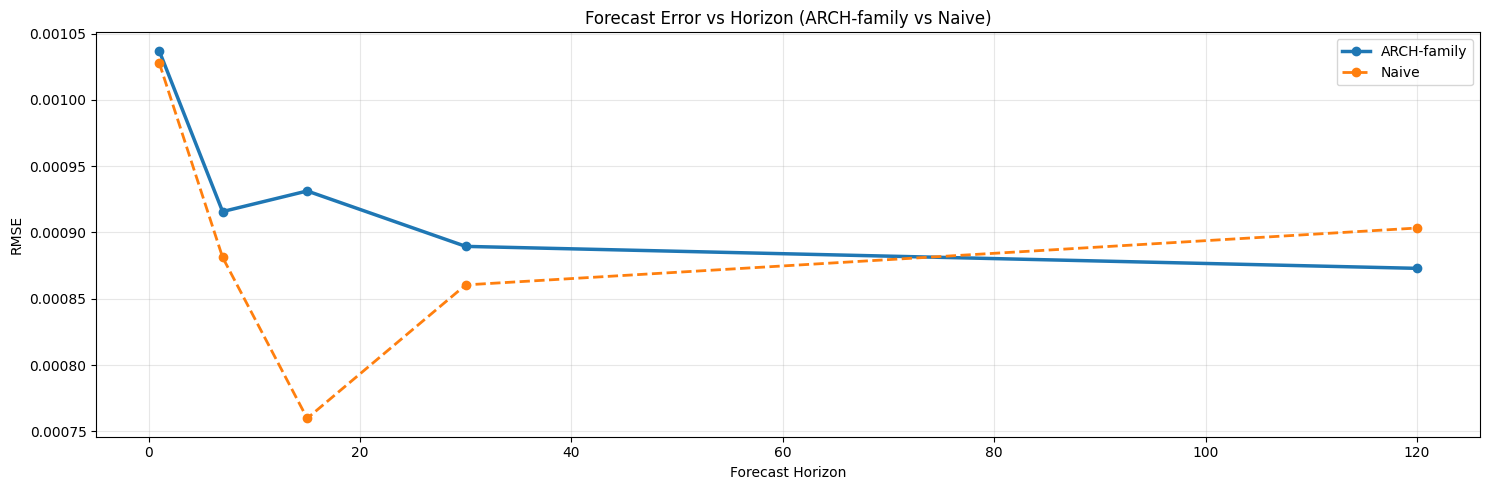

In [48]:
# Compare ARCH-family model vs Naive on test set across horizons
def plot_model_comparison_vs_horizon(df_compare: pd.DataFrame):
    """
    Plot forecast error vs horizon comparing the selected ARCH-family model and Naive.
    """

    # Identify RMSE columns
    rmse_cols = sorted([c for c in df_compare.columns if c.startswith("RMSE-h=")],
                       key=lambda x: int(x.split("=")[1]))

    horizons = [int(c.split("=")[1]) for c in rmse_cols]

    # ARCH-family row
    arch_row = df_compare[df_compare["model"] != "naive"].iloc[0]
    arch_rmse = arch_row[rmse_cols].values.astype(float)

    # Naive row
    naive_row = df_compare[df_compare["model"] == "naive"].iloc[0]
    naive_rmse = naive_row[rmse_cols].values.astype(float)

    plt.figure(figsize=(15, 5))

    plt.plot(horizons, arch_rmse, marker="o", linewidth=2.5, label="ARCH-family")
    plt.plot(horizons, naive_rmse, marker="o", linestyle="--", linewidth=2, label="Naive")

    plt.title("Forecast Error vs Horizon (ARCH-family vs Naive)")
    plt.xlabel("Forecast Horizon")
    plt.ylabel("RMSE")

    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_model_comparison_vs_horizon(df_compare)

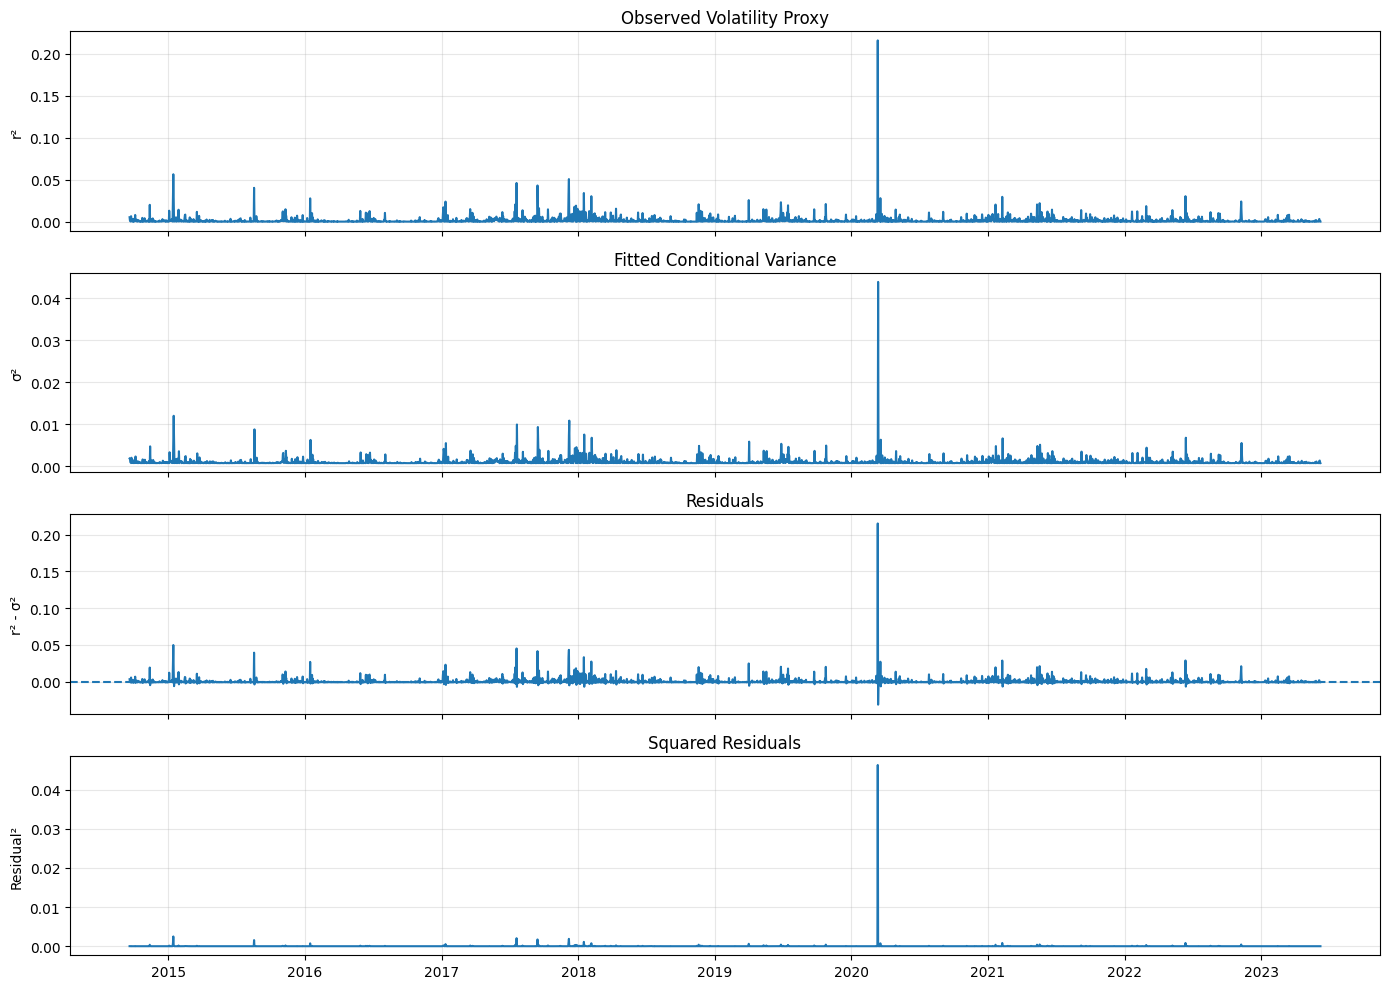

In [49]:
# Plot ARCH-family fit diagnostics: observed volatility proxy, fitted conditional variance,
# residuals and squared residuals

fit = residual_pack["fit"]
y_dev_used = residual_pack["y_dev_used"]
fitted = residual_pack["fitted_values"]
residuals = residual_pack["residuals"]

# Observed development series in volatility-proxy scale: r_t²
y_dev_original = y_dev_used.astype(float).pow(2).rename("Observed")

# Align all series to the same index
common_index = (y_dev_original.index.intersection(fitted.index).intersection(residuals.index))

y_dev_plot = y_dev_original.loc[common_index]
fitted_plot = fitted.loc[common_index]
residuals_plot = residuals.loc[common_index]

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

# Observed volatility proxy
axes[0].plot(y_dev_plot.index, y_dev_plot.values)
axes[0].set_title("Observed Volatility Proxy")
axes[0].set_ylabel("r²")

# Fitted conditional variance
axes[1].plot(fitted_plot.index, fitted_plot.values)
axes[1].set_title("Fitted Conditional Variance")
axes[1].set_ylabel("σ²")

# Residuals: r_t² - σ_t²
axes[2].plot(residuals_plot.index, residuals_plot.values)
axes[2].axhline(0, linestyle="--")
axes[2].set_title("Residuals")
axes[2].set_ylabel("r² - σ²")

# Squared residuals
axes[3].plot(residuals_plot.index, residuals_plot.values ** 2)
axes[3].set_title("Squared Residuals")
axes[3].set_ylabel("Residual²")

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()